## Warmup: interesting demo

1. https://bbycroft.net/llm - interactive 3d llm visualization
2. https://tiktokenizer.vercel.app/ - interactive tokenizer

## Setup

Run this cell first — it is used later to render the interactive plots inline.

In [129]:
def _show_html(path, height=650):
    """Embed an already-written standalone HTML file inline as an output.
    Uses srcdoc (content inlined into the iframe) rather than src (a file
    path/URL) so it renders regardless of how the notebook viewer resolves
    external paths."""
    import html as _html
    from IPython.display import HTML, display
    with open(path, encoding="utf-8") as f:
        content = f.read()
    display(HTML(f'<iframe srcdoc="{_html.escape(content)}" '
                 f'width="100%" height="{height}" style="border:none"></iframe>'))


# 01 — Tokenizer lab

**Lecture 1, block 1** (BPE, byte-level BPE, vocab size trade-offs, tokenizer tax).

What this section covers:
1. The same meaning in different languages costs a DIFFERENT number of tokens (tokenizer tax).
2. Vocab size ↔ sequence length ↔ size of the embedding/head matrices — this is one trade-off.
3. The tokenizer pathologies from the memes (`strawberry`, numbers, glitch tokens)
   follow from how BPE works, not from the model's "reasoning".

```bash
pip install tiktoken transformers matplotlib
```
`transformers` is only needed for the HF-tokenizer section (Llama/Qwen/Gemma) — it is optional.

In [130]:
from __future__ import annotations

import os
import sys
from collections import Counter
from pathlib import Path

OUT = Path("out")
OUT.mkdir(exist_ok=True)

os.system("")  # enables ANSI colors in cmd.exe/PowerShell on Windows
if hasattr(sys.stdout, "reconfigure"):  # the Windows console is not utf-8 by default
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

try:
    import tiktoken
except ImportError:
    sys.exit("tiktoken required:  pip install tiktoken")

## Parallel corpus

Article 1 of the Universal Declaration of Human Rights (UN, public domain) — the canonical
parallel text: the same meaning, 6 languages + different writing systems.
Plus a snippet of code and a formula — to see that "language" here is not only natural language.

In [131]:
PARALLEL = {
    "en": "All human beings are born free and equal in dignity and rights. "
          "They are endowed with reason and conscience and should act towards "
          "one another in a spirit of brotherhood.",
    "ru": "Все люди рождаются свободными и равными в своём достоинстве и правах. "
          "Они наделены разумом и совестью и должны поступать в отношении друг друга "
          "в духе братства.",
    "de": "Alle Menschen sind frei und gleich an Würde und Rechten geboren. "
          "Sie sind mit Vernunft und Gewissen begabt und sollen einander im Geiste "
          "der Brüderlichkeit begegnen.",
    "fr": "Tous les êtres humains naissent libres et égaux en dignité et en droits. "
          "Ils sont doués de raison et de conscience et doivent agir les uns envers "
          "les autres dans un esprit de fraternité.",
    "zh": "人人生而自由，在尊严和权利上一律平等。他们赋有理性和良心，"
          "并应以兄弟关系的精神相对待。",
    "hy": "Բոլոր մարդիկ ծնվում են ազատ ու հավասար իրենց արժանապատվությամբ և իրավունքներով։",
}

CODE = '''\
def attention(q, k, v, mask=None):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    return torch.softmax(scores, dim=-1) @ v
'''

ENCODERS = {
    "gpt2 (50k)":       tiktoken.get_encoding("gpt2"),
    "cl100k (GPT-4)":   tiktoken.get_encoding("cl100k_base"),
    "o200k (GPT-4o)":   tiktoken.get_encoding("o200k_base"),
}

## 1. Tokenizer tax: what the same meaning costs

**Fertility** = tokens per word. The key metric when picking a tokenizer for a language.
We also look at bytes/token — how much "useful information" a single token carries.

In [132]:
def fertility_table(texts: dict[str, str], encoders: dict) -> None:
    """Two metrics per tokenizer:
    tok    — how many tokens the text took (the direct price, in money and in generation steps);
    ch/tok — how many characters one token carries (how densely the context is packed).
    Fertility, "tokens per word", is printed separately: Chinese has no words.
    """
    head = f"{'lang':<6}{'chars':>6}{'bytes':>6}" + "".join(f"{n:>18}" for n in encoders)
    print(head + "\n" + "-" * len(head))
    for lang, text in texts.items():
        row = f"{lang:<6}{len(text):>6}{len(text.encode('utf-8')):>6}"
        for enc in encoders.values():
            n_tok = len(enc.encode(text))
            row += f"{n_tok:>11}{len(text) / n_tok:>7.2f}"
        print(row)
    print("(each column: tokens | characters per token — higher = better compression)\n")

    print(f"{'lang':<6}{'words':>6}" + "".join(f"{n:>18}" for n in encoders))
    for lang, text in texts.items():
        n_words = len(text.split())
        if n_words < 3:      # Chinese: no spaces, per-word fertility is meaningless
            continue
        row = f"{lang:<6}{n_words:>6}"
        for enc in encoders.values():
            row += f"{len(enc.encode(text)) / n_words:>18.2f}"
        print(row)
    print("(fertility = tokens per word)")


print("=== UDHR Article 1 — one meaning, different languages ===\n")
fertility_table(PARALLEL, ENCODERS)

print("\n=== Code ===\n")
fertility_table({"python": CODE}, ENCODERS)

=== UDHR Article 1 — one meaning, different languages ===

lang   chars bytes        gpt2 (50k)    cl100k (GPT-4)    o200k (GPT-4o)
------------------------------------------------------------------------
en       170   170         33   5.15         33   5.15         33   5.15
ru       160   293        173   0.92         75   2.13         42   3.81
de       165   167         60   2.75         44   3.75         39   4.23
fr       186   191         61   3.05         50   3.72         41   4.54
zh        43   129         86   0.50         50   0.86         35   1.23
hy        79   148        148   0.53        148   0.53         22   3.59
(each column: tokens | characters per token — higher = better compression)

lang   words        gpt2 (50k)    cl100k (GPT-4)    o200k (GPT-4o)
en        30              1.10              1.10              1.10
ru        26              6.65              2.88              1.62
de        26              2.31              1.69              1.50
fr        34 

**Takeaway.** English is ≈ 1.3 tokens/word, Russian on gpt2 is ≈ 3–4.
This is not "the model knows Russian worse" — it is literally more expensive:

* more expensive in money: billing is per token;
* shorter effective context: 128k tokens is ~90k English words and ~35k Russian ones;
* more expensive inference: generation is token by token, so for the same answer
  in Russian the model runs 2.5–3× more forward passes.

And separately: o200k (GPT-4o) was deliberately extended for multilinguality — you can see it
in the fertility drop on ru/zh relative to cl100k. That is an architectural decision, not magic.

In [133]:
# How many times more expensive Russian is than English, per tokenizer
print("ru/en token-count ratio (same meaning — how many times more expensive):")
for name, enc in ENCODERS.items():
    r = len(enc.encode(PARALLEL["ru"])) / len(enc.encode(PARALLEL["en"]))
    print(f"  {name:<18} x{r:.2f}")

# a separate "aha" moment: a language that is not in the vocab at all
hy = PARALLEL["hy"]
for name in ("gpt2 (50k)", "cl100k (GPT-4)"):
    n_tok = len(ENCODERS[name].encode(hy))
    print(f"\n{name} on Armenian: {n_tok} tokens for {len(hy.encode('utf-8'))} bytes "
          f"= {n_tok / len(hy.encode('utf-8')):.2f} tokens per BYTE")
print("→ this is pure byte mode: the vocab holds not a single merge for this script.")
print("  One character = 2 bytes = 2 tokens. The worst case of byte-level BPE — and it is real.")
print(f"  o200k: {len(ENCODERS['o200k (GPT-4o)'].encode(hy))} tokens — Armenian made it into that vocab.")

ru/en token-count ratio (same meaning — how many times more expensive):
  gpt2 (50k)         x5.24
  cl100k (GPT-4)     x2.27
  o200k (GPT-4o)     x1.27

gpt2 (50k) on Armenian: 148 tokens for 148 bytes = 1.00 tokens per BYTE

cl100k (GPT-4) on Armenian: 148 tokens for 148 bytes = 1.00 tokens per BYTE
→ this is pure byte mode: the vocab holds not a single merge for this script.
  One character = 2 bytes = 2 tokens. The worst case of byte-level BPE — and it is real.
  o200k: 22 tokens — Armenian made it into that vocab.


## 2. Seeing token boundaries with your own eyes

Just colour the tokens. What is visible here:
* the leading space is part of the token (`" the"` ≠ `"the"`), which is why spaces are nearly free;
* Cyrillic is cut into 1–2 character pieces (and on gpt2 into raw bytes, hence the `�`);
* numbers are not split along digit groups.

In [134]:
PALETTE = [f"\033[48;5;{c}m\033[38;5;16m" for c in (117, 150, 224, 222, 189, 210, 158, 183)]
RESET = "\033[0m"


def show_tokens(text: str, enc, label: str = "") -> list[int]:
    ids = enc.encode(text)
    parts = []
    for i, tid in enumerate(ids):
        piece = enc.decode_single_token_bytes(tid).decode("utf-8", errors="replace")
        parts.append(f"{PALETTE[i % len(PALETTE)]}{piece}{RESET}")
    print(f"{label} [{len(ids)} tokens]")
    print("".join(parts))
    print()
    return ids


for name, enc in ENCODERS.items():
    show_tokens(PARALLEL["ru"], enc, label=name)

show_tokens(CODE, ENCODERS["gpt2 (50k)"], label="gpt2 on code (note the indentation)")
show_tokens(CODE, ENCODERS["cl100k (GPT-4)"], label="cl100k on code (indentation collapsed into one token)")

gpt2 (50k) [173 tokens]
��се ����ди ро��да��тся сво��о��ными �� равными �� сво��м ��остоинстве �� ��рава��. ��ни ��аделены ра��умо�� �� со��есть�� �� ��о����ны ��осту��ать �� ��тно��ении ��ру�� ��ру��а �� ��у��е ��ратства.

cl100k (GPT-4) [75 tokens]
Все люди рождаются свободными и ра��ными в своём достоинстве и правах. Они наделены разумом и совестью и должны поступать в отношении друг друга в духе братства.

o200k (GPT-4o) [42 tokens]
Все люди рождаются свободными и равными в своём достоинстве и правах. Они наделены разумом и совестью и должны поступать в отношении друг друга в духе братства.

gpt2 on code (note the indentation) [99 tokens]
def attention(q, k, v, mask=None):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    return torch.softmax(scores, dim=-1) @ v


cl100k on code (indentation collapsed into one token) [68 tokens]
def attention(q, k, v, mask=None):
    scores = q @ k

[755,
 6666,
 10806,
 11,
 597,
 11,
 348,
 11,
 7056,
 5980,
 997,
 262,
 12483,
 284,
 2874,
 571,
 597,
 36405,
 4172,
 17,
 11,
 482,
 16,
 8,
 611,
 7033,
 18540,
 10806,
 2546,
 4172,
 16,
 1192,
 262,
 422,
 7056,
 374,
 539,
 2290,
 512,
 286,
 12483,
 284,
 12483,
 36279,
 291,
 31828,
 36406,
 624,
 220,
 15,
 11,
 2273,
 13959,
 13885,
 5572,
 262,
 471,
 7990,
 76272,
 64219,
 11,
 5213,
 11065,
 16,
 8,
 571,
 348,
 198]

### HTML version for the projector
ANSI in the terminal is fine, but in HTML you can hover and see the token id.

In [135]:
HTML_COLORS = ["#a8d5ff", "#b8e6c1", "#d4c5f9", "#ffd9a0", "#ffc9d4", "#c9f0e8", "#f7f0a0", "#e6c9a8"]


def dump_html(samples: dict[str, tuple[str, object]], path: Path) -> None:
    blocks = []
    for title, (text, enc) in samples.items():
        ids = enc.encode(text)
        spans = []
        for i, tid in enumerate(ids):
            piece = enc.decode_single_token_bytes(tid).decode("utf-8", errors="replace")
            piece = piece.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
            piece = piece.replace(" ", "&nbsp;").replace("\n", "⏎<br>")
            spans.append(
                f'<span class="t" style="background:{HTML_COLORS[i % len(HTML_COLORS)]}" '
                f'title="id={tid}">{piece}</span>'
            )
        blocks.append(f"<h2>{title} <small>— {len(ids)} tokens</small></h2><p>{''.join(spans)}</p>")
    path.write_text(
        "<meta charset='utf-8'><title>Token boundaries</title><style>"
        "body{font-family:system-ui;max-width:900px;margin:40px auto;line-height:2.2}"
        ".t{padding:2px 1px;border-radius:3px;font-family:ui-monospace,Consolas,monospace}"
        "h2{font-size:16px;color:#444;margin-top:32px}</style>" + "".join(blocks),
        encoding="utf-8",
    )
    print(f"→ {path}")


dump_html(
    {
        f"{lang} · {name}": (text, enc)
        for lang, text in PARALLEL.items()
        for name, enc in ENCODERS.items()
    },
    OUT / "01_tokens.html",
)
_show_html(OUT / "01_tokens.html", height=500)

→ out\01_tokens.html


c:\Users\denis\miniconda3\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## 3. Pathologies: why the model "cannot" count letters

None of these examples is about intelligence — they are about the model never having seen characters.

In [136]:
enc = ENCODERS["cl100k (GPT-4)"]

print("--- strawberry: why counting 'r' is hard ---")
show_tokens("strawberry", enc, label="how the model sees the word")
print("The model sees 3 opaque ids. To count the 'r's it would have to KNOW the letter")
print("composition of each token — that information is not directly in the embedding, it is")
print("only learned statistically. Compare the per-character variant:")
show_tokens("s t r a w b e r r y", enc, label="the same word, spread out into letters")

print("--- Numbers: arithmetic breaks on tokenization ---")
for n in ["1234567", "1 234 567", "127", "128", "1000000", "3.14159"]:
    ids = enc.encode(n)
    pieces = [enc.decode_single_token_bytes(t).decode("utf-8", "replace") for t in ids]
    print(f"  {n:>10} -> {pieces}")
print("cl100k splits numbers into groups of up to 3 digits, but NOT aligned to place value.")
print("That is why Llama-3 and several others split digits one by one — at the cost of length.\n")

print("--- Whitespace and case: different tokens for one word ---")
for s in ["the", " the", "The", " The", " THE", "\tthe"]:
    print(f"  {s!r:>10} -> {enc.encode(s)}")
print()

print("--- Trailing whitespace: the classic prompt bug ---")
print(f"  {'Answer:'!r}  -> {enc.encode('Answer:')}")
print(f"  {'Answer: '!r} -> {enc.encode('Answer: ')}")
print("A trailing space in the prompt moves the model into a different part of the distribution:")
print("continuations after ':' and after ': ' are different tokens with different statistics.\n")

--- strawberry: why counting 'r' is hard ---
how the model sees the word [3 tokens]
strawberry

The model sees 3 opaque ids. To count the 'r's it would have to KNOW the letter
composition of each token — that information is not directly in the embedding, it is
only learned statistically. Compare the per-character variant:
the same word, spread out into letters [10 tokens]
s t r a w b e r r y

--- Numbers: arithmetic breaks on tokenization ---
     1234567 -> ['123', '456', '7']
   1 234 567 -> ['1', ' ', '234', ' ', '567']
         127 -> ['127']
         128 -> ['128']
     1000000 -> ['100', '000', '0']
     3.14159 -> ['3', '.', '141', '59']
cl100k splits numbers into groups of up to 3 digits, but NOT aligned to place value.
That is why Llama-3 and several others split digits one by one — at the cost of length.

--- Whitespace and case: different tokens for one word ---
       'the' -> [1820]
      ' the' -> [279]
       'The' -> [791]
      ' The' -> [578]
      ' THE' -> [3247]
  

### Glitch tokens
Tokens that entered the vocab from junk data (forum handles, scraping artifacts) but barely
occurred in the training corpus → their embeddings stayed near initialization.
The model behaves unpredictably on them. The canonical example is ` SolidGoldMagikarp` (GPT-2/GPT-3).

Let us check: such a token exists, and it is a SINGLE one.

In [137]:
gpt2 = ENCODERS["gpt2 (50k)"]
for s in [" SolidGoldMagikarp", " petertodd", " davidjl", " Mechdragon"]:
    ids = gpt2.encode(s)
    print(f"  {s!r:>22} -> {ids}  ({'ONE token!' if len(ids) == 1 else f'{len(ids)} tokens'})")
print("\nThe vocab is built on ONE corpus, while training runs on ANOTHER (filtered) one.")
print("Tokens that survived the first and died out in the second are undertrained embeddings.")
print("Paper: 'Fishing for Magikarp' (Land & Bartolo, 2024), arxiv.org/abs/2405.05417")

    ' SolidGoldMagikarp' -> [43453]  (ONE token!)
            ' petertodd' -> [37444]  (ONE token!)
              ' davidjl' -> [23282]  (ONE token!)
           ' Mechdragon' -> [35579]  (ONE token!)

The vocab is built on ONE corpus, while training runs on ANOTHER (filtered) one.
Tokens that survived the first and died out in the second are undertrained embeddings.
Paper: 'Fishing for Magikarp' (Land & Bartolo, 2024), arxiv.org/abs/2405.05417


## 4. Vocab size ↔ sequence length ↔ parameters

The main quantitative story of this block. Computed on real text:
a bigger vocab → shorter sequences → fewer attention steps,
BUT a fatter embedding + LM head (both matrices are V×d).

In [138]:
import math

CORPUS = " ".join(PARALLEL.values()) * 20 + CODE * 20

print(f"{'tokenizer':<18}{'V':>8}{'tokens':>10}{'bytes/tok':>10}{'emb+head @ d=2048':>22}")
print("-" * 68)
n_bytes = len(CORPUS.encode("utf-8"))
for name, e in ENCODERS.items():
    n_tok = len(e.encode(CORPUS))
    V = e.n_vocab
    d = 2048
    emb = 2 * V * d / 1e6  # embedding + LM head, without tying
    print(f"{name:<18}{V:>8}{n_tok:>10}{n_bytes / n_tok:>9.2f}B{emb:>19.1f}M")

print("""
Takeaway:
  • Every token we "saved" is a forward pass that will not happen.
    Attention compute falls QUADRATICALLY in length, the FFN linearly.
  • But embedding+head grow LINEARLY in V. At d=2048, going from a 50k to a 200k vocab
    adds ~600M parameters — more than an entire 0.5B model weighs.
  • Hence the rule: big vocabs are for big models. Small models (SmolLM, Qwen3-0.6B)
    tie the input/output embedding and still keep 20–40% of the budget in the vocab.
  • And hence Gemma with V=262144: they pay for multilinguality, but they have 27B parameters,
    against which V·d no longer dominates.
""")

tokenizer                V    tokens bytes/tok     emb+head @ d=2048
--------------------------------------------------------------------
gpt2 (50k)           50257     13240     2.01B              205.9M
cl100k (GPT-4)      100277      9400     2.83B              410.7M
o200k (GPT-4o)      200019      5600     4.75B              819.3M

Takeaway:
  • Every token we "saved" is a forward pass that will not happen.
    Attention compute falls QUADRATICALLY in length, the FFN linearly.
  • But embedding+head grow LINEARLY in V. At d=2048, going from a 50k to a 200k vocab
    adds ~600M parameters — more than an entire 0.5B model weighs.
  • Hence the rule: big vocabs are for big models. Small models (SmolLM, Qwen3-0.6B)
    tie the input/output embedding and still keep 20–40% of the budget in the vocab.
  • And hence Gemma with V=262144: they pay for multilinguality, but they have 27B parameters,
    against which V·d no longer dominates.



## 5. (optional) HF tokenizers of real models

Requires `transformers` and network access. Shows that "byte-level BPE" is not one algorithm
but a family, with different pre-tokenization regexes and different decisions about digits.

In [139]:
HF_MODELS = [
    "meta-llama/Llama-3.1-8B",     # gated: needs an HF token
    "Qwen/Qwen3-8B",
    "google/gemma-3-4b-it",        # gated
    "openai/gpt-oss-20b",
    "HuggingFaceTB/SmolLM3-3B",
]

try:
    from transformers import AutoTokenizer

    print(f"{'model':<32}{'V':>8}{'ru tok':>8}{'en tok':>8}{'ru/en':>7}")
    print("-" * 63)
    for mid in HF_MODELS:
        try:
            tok = AutoTokenizer.from_pretrained(mid)
        except Exception as exc:  # gated / no network
            print(f"{mid:<32}  — skipped ({type(exc).__name__})")
            continue
        ru = len(tok.encode(PARALLEL["ru"], add_special_tokens=False))
        en = len(tok.encode(PARALLEL["en"], add_special_tokens=False))
        print(f"{mid:<32}{len(tok):>8}{ru:>8}{en:>8}{ru / en:>7.2f}")
        print(f"    123456789 -> {tok.tokenize('123456789')}")
except ImportError:
    print("transformers is not installed — section skipped (pip install transformers)")

model                                  V  ru tok  en tok  ru/en
---------------------------------------------------------------
meta-llama/Llama-3.1-8B           128256      48      33   1.45
    123456789 -> ['123', '456', '789']
Qwen/Qwen3-8B                     151669      50      33   1.52
    123456789 -> ['1', '2', '3', '4', '5', '6', '7', '8', '9']
google/gemma-3-4b-it              262145      40      32   1.25
    123456789 -> ['1', '2', '3', '4', '5', '6', '7', '8', '9']
openai/gpt-oss-20b                200019      42      33   1.27
    123456789 -> ['123', '456', '789']
HuggingFaceTB/SmolLM3-3B          128256      48      33   1.45
    123456789 -> ['123', '456', '789']


## Takeaways: what the tokenizer decides

| Observation | Consequence for the architecture |
|---|---|
| fertility(ru) ≈ 2–3× fertility(en) | non-Latin script is more expensive in everything: price, context, latency |
| the leading space is part of the token | prompt engineering: do not put a space at the end |
| numbers are not split by place value | Llama-3 and others split digits one by one for arithmetic's sake |
| undertrained embeddings exist | the vocab and the training corpus must match |
| V sets 2·V·d parameters | the tokenizer's share of the model budget is the first line of the estimate |

**Next:** we train BPE by hand and see where all of this comes from.

---

# 02 — BPE by hand (live coding)

**Lecture 1, block 1.** Zero dependencies besides matplotlib.

The order we build it in:
1. `get_stats` — count frequencies of adjacent pairs
2. `merge` — replace the most frequent pair with a new id
3. `train` — the loop: find → merge → record the rule
4. `encode` / `decode` — apply the rules in the same order

And then the three experiments this was all written for:
* where the "Cyrillic tax" comes from (spoiler: from the composition of the tokenizer's corpus);
* what the pre-tokenization regex is for;
* what the "compression vs vocab size" curve looks like.

In [140]:
from __future__ import annotations

import re
import sys
from collections import Counter
from pathlib import Path

if hasattr(sys.stdout, "reconfigure"):  # the Windows console is not utf-8 by default
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)

## The core of the algorithm

In [141]:
def get_stats(ids: list[int], counts: Counter | None = None) -> Counter:
    """Frequencies of adjacent pairs. The Counter is passed in so we can accumulate over chunks."""
    counts = Counter() if counts is None else counts
    counts.update(zip(ids, ids[1:]))
    return counts


def merge(ids: list[int], pair: tuple[int, int], new_id: int) -> list[int]:
    """Replace every occurrence of pair with new_id. Left to right, no overlaps."""
    out, i = [], 0
    while i < len(ids):
        if i < len(ids) - 1 and (ids[i], ids[i + 1]) == pair:
            out.append(new_id)
            i += 2
        else:
            out.append(ids[i])
            i += 1
    return out


class BPE:
    """Byte-level BPE. Exactly what is inside tiktoken/GPT-2, just without the optimizations."""

    # pre-tokenization: cut the text into chunks INSIDE which merging pairs is allowed.
    # Merges never cross a chunk boundary. This is the simplified GPT-2/cl100k regex,
    # rewritten for the `re` module (which has no \p{L}/\p{N}: letters = [^\W\d_], digits = \d).
    #
    # Watch the underscore. In the original, punctuation is "not whitespace, not \p{L},
    # not \p{N}", and `_` lands there. Here `\w` stands in for letters-and-digits — but `\w`
    # INCLUDES `_`, so `_` is excluded from the letters branch and from the punctuation branch
    # at once, matches nothing, and `findall` silently drops it. Hence the explicit `|_`
    # below: without it `decode(encode("snake_case")) == "snakecase"`.
    SPLIT_PAT = re.compile(
        r"'(?:s|t|re|ve|m|ll|d)"   # English clitics: 'll, 've, ...
        r"| ?[^\W\d_]+"            # (space +) letters  ← the leading space attaches here
        r"| ?\d{1,3}"              # (space +) AT MOST THREE digits — the cl100k rule
        r"| ?(?:[^\s\w]|_)+"       # (space +) punctuation — `_` spelled out, see above
        r"|\s+(?!\S)"              # trailing whitespace
        r"|\s+",                   # remaining whitespace
        re.IGNORECASE,
    )

    def __init__(self, use_regex: bool = True):
        self.merges: dict[tuple[int, int], int] = {}
        self.vocab: dict[int, bytes] = {i: bytes([i]) for i in range(256)}
        self.use_regex = use_regex
        self.log: list[tuple[int, tuple[int, int], bytes, int]] = []

    def _chunks(self, text: str) -> list[list[int]]:
        parts = self.SPLIT_PAT.findall(text) if self.use_regex else [text]
        return [list(p.encode("utf-8")) for p in parts if p]

    def train(self, text: str, vocab_size: int, verbose: int = 0) -> None:
        chunks = self._chunks(text)
        for i in range(256, vocab_size):
            stats = Counter()
            for ch in chunks:
                get_stats(ch, stats)
            if not stats:
                break
            pair, freq = stats.most_common(1)[0]
            if freq < 2:
                break
            chunks = [merge(ch, pair, i) for ch in chunks]
            self.merges[pair] = i
            self.vocab[i] = self.vocab[pair[0]] + self.vocab[pair[1]]
            # bookkeeping for the merge log we print below — not worth typing by hand
            self.log.append((i, pair, self.vocab[i], freq))
            if verbose and (i - 256) < verbose:
                shown = self.vocab[i].decode("utf-8", errors="replace")
                print(f"  merge #{i - 255:<4} id={i:<5} {shown!r:<14} (freq {freq})")

    def encode(self, text: str) -> list[int]:
        out = []
        for ids in self._chunks(text):
            while len(ids) >= 2:
                # take the pair with the LOWEST merge index: the rules are applied
                # strictly in the order they were learned
                stats = get_stats(ids)
                pair = min(stats, key=lambda p: self.merges.get(p, float("inf")))
                if pair not in self.merges:
                    break
                ids = merge(ids, pair, self.merges[pair])
            out.extend(ids)
        return out

    def decode(self, ids: list[int]) -> str:
        return b"".join(self.vocab[i] for i in ids).decode("utf-8", errors="replace")

## Corpus

We deliberately make the corpus **imbalanced**: 80% English, 20% Russian.
It is a model of what actually happens with a web crawl.

In [142]:
EN = (
    "The transformer architecture replaced recurrence with attention. "
    "Attention lets every position read from every other position in one step. "
    "The model is a stack of identical blocks over a residual stream. "
    "Each block has an attention sublayer and a feed forward sublayer. "
    "Training is parallel over positions, inference is sequential over tokens. "
)
RU = (
    "Трансформер заменил рекуррентность вниманием. "
    "Внимание позволяет каждой позиции читать из любой другой позиции за один шаг. "
    "Модель — это стек одинаковых блоков над остаточным потоком. "
)

# held-out: these sentences were NOT in the tokenizer's training text.
# Measuring fertility on the training text is self-deception: BPE has memorized it.
EN_TEST = ("The residual stream carries information across the depth of the network "
           "and every sublayer both reads from it and writes back into it.")
RU_TEST = ("Остаточный поток переносит информацию сквозь всю глубину сети, "
           "и каждый подслой одновременно и читает из него, и пишет в него обратно.")
# The two are translations of each other AND worded to the same character count, on
# purpose: with the lengths matched, any difference in the token count below is the
# tokenizer's doing and nothing else. Keep the assert — it is easy to "improve" the
# wording of one of them and silently reintroduce a length confound.
assert len(EN_TEST) == len(RU_TEST), "the held-out pair must stay length-matched"

CORPUS = EN * 60 + RU * 3  # web crawls can be even more skewed
ru_bytes = len(RU.encode("utf-8")) * 3
print(f"corpus: {len(CORPUS)} characters, {len(CORPUS.encode('utf-8'))} bytes")
print(f"Russian share: by characters {len(RU) * 3 / len(CORPUS):.1%}, "
      f"by bytes {ru_bytes / len(CORPUS.encode('utf-8')):.1%}")
print("↑ the tax starts before BPE: Cyrillic takes 2 bytes per character, Latin takes 1.\n")

corpus: 21192 characters, 21663 bytes
Russian share: by characters 2.6%, by bytes 4.7%
↑ the tax starts before BPE: Cyrillic takes 2 bytes per character, Latin takes 1.



## Experiment 1: watching the vocab being born

In [143]:
print("First 25 merges:\n")
tok = BPE(use_regex=True)
tok.train(CORPUS, vocab_size=256 + 200, verbose=25)

print("\nLast 5 merges (whole words by now):")
for i, pair, piece, freq in tok.log[-5:]:
    print(f"  id={i:<5} {piece.decode('utf-8', 'replace')!r:<20} (freq {freq})")

First 25 merges:

  merge #1    id=256   'er'           (freq 600)
  merge #2    id=257   ' a'           (freq 480)
  merge #3    id=258   'en'           (freq 480)
  merge #4    id=259   'ti'           (freq 480)
  merge #5    id=260   'on'           (freq 420)
  merge #6    id=261   're'           (freq 360)
  merge #7    id=262   'tion'         (freq 360)
  merge #8    id=263   ' i'           (freq 360)
  merge #9    id=264   ' s'           (freq 360)
  merge #10   id=265   'ver'          (freq 300)
  merge #11   id=266   ' o'           (freq 300)
  merge #12   id=267   ' re'          (freq 240)
  merge #13   id=268   ' p'           (freq 240)
  merge #14   id=269   'si'           (freq 240)
  merge #15   id=270   'al'           (freq 240)
  merge #16   id=271   'bl'           (freq 240)
  merge #17   id=272   'ac'           (freq 180)
  merge #18   id=273   'tt'           (freq 180)
  merge #19   id=274   'tten'         (freq 180)
  merge #20   id=275   'ttention'     (freq 180)
  

**Discussion.** Merges go bottom-up: first letter pairs, then syllables, then whole frequent
words with a leading space (`" attention"`). No linguistics at all — only frequency.
Two immediate consequences:
* a token ≈ a frequent substring, not a morpheme; a "word" is just a very frequent substring;
* the leading space attaches to the word because `" a"` occurs more often than `"a"` alone.

## Experiment 2: where the Cyrillic tax comes from

There are two independent mechanisms here, and it matters to keep them separate.

**(a) Cyrillic starts one level lower.** In byte-level BPE the alphabet is 256 bytes,
so only ASCII characters come for free. Every Cyrillic letter is 2 bytes, so the first merges
for Russian are spent just assembling A SINGLE LETTER.
English is already assembling syllables at that point.

In [144]:
big = BPE()
big.train(CORPUS, vocab_size=256 + 500)

def as_single_char(p: bytes) -> str | None:
    try:
        s = p.decode("utf-8")
    except UnicodeDecodeError:
        return None
    return s if len(s) == 1 and not s.isascii() else None


single_char = [c for _, _, p, _ in big.log if (c := as_single_char(p))]
print(f"merges spent assembling ONE non-ASCII character: {len(single_char)} of {len(big.log)}")
print("  for example:", single_char[:14])
print("(in the merge log such pieces show up as ' \\ufffd' — that is half a letter)\n")

merges spent assembling ONE non-ASCII character: 14 of 304
  for example: ['о', 'и', 'а', 'н', 'т', 'е', 'р', 'м', 'с', 'л', 'ь', 'к', 'у', 'ы']
(in the merge log such pieces show up as ' \ufffd' — that is half a letter)



**(b) Whoever is underrepresented in the corpus does not win merges.**
We measure fertility on **held-out** text: BPE knows the text it was trained on by heart.

In [145]:
def language_of(piece: bytes) -> str:
    s = piece.decode("utf-8", errors="ignore")
    if any("а" <= c.lower() <= "я" or c == "ё" for c in s):
        return "ru"
    if any(c.isascii() and c.isalpha() for c in s):
        return "en"
    return "other"


shares = Counter(language_of(p) for _, _, p, _ in big.log)
print(f"of {len(big.log)} merges: en={shares['en']}, ru={shares['ru']}, other={shares['other']}\n")

# chars/token, not bytes/token: a Cyrillic character costs 2 UTF-8 bytes and a Latin one
# costs 1, so bytes/token rewards Cyrillic for exactly what makes it expensive. Both
# sentences are the same length in characters, so this column compares like with like.
print(f"{'held-out':<8}{'tokens':>9}{'words':>6}{'fertility':>11}"
      f"{'chars/token':>13}{'bytes/token':>13}")
print("-" * 61)
for lang, sample in [("en", EN_TEST), ("ru", RU_TEST)]:
    ids = big.encode(sample)
    words, nbytes = len(sample.split()), len(sample.encode("utf-8"))
    print(f"{lang:<8}{len(ids):>9}{words:>6}{len(ids) / words:>11.2f}"
          f"{len(sample) / len(ids):>13.2f}{nbytes / len(ids):>13.2f}")

print("""
Read the table like this:
  • fertility (tokens per word) is the direct price: that many forward passes per word;
  • chars/token is how saturated a token is: how much text one context position carries.
Both are worse for Russian, and this is BEFORE the model has started training at all.

The last column is a trap, and it is kept here on purpose. By BYTES per token Russian comes
out AHEAD of English — an artefact of UTF-8, not a fact about the tokenizer: one Cyrillic
character is two bytes, so the same token covers twice the bytes while covering half the
text. Whenever a tokenizer comparison crosses alphabets, count characters, not bytes.

The full mechanism: BPE greedily optimizes compression of the TOKENIZER's training corpus.
A language that is scarce there stays close to the byte level. Hence:
  • GPT-2 (a mostly English corpus) has a Russian fertility of ~3.5;
  • o200k (GPT-4o, whose vocab was deliberately extended for multilinguality) is markedly lower.
This is not "the model knows the language worse", it is a decision made at the tokenizer stage.
""")

of 304 merges: en=155, ru=143, other=6

held-out   tokens words  fertility  chars/token  bytes/token
-------------------------------------------------------------
en             69    23       3.00         1.94         1.94
ru            113    21       5.38         1.19         2.17

Read the table like this:
  • fertility (tokens per word) is the direct price: that many forward passes per word;
  • chars/token is how saturated a token is: how much text one context position carries.
Both are worse for Russian, and this is BEFORE the model has started training at all.

The last column is a trap, and it is kept here on purpose. By BYTES per token Russian comes
out AHEAD of English — an artefact of UTF-8, not a fact about the tokenizer: one Cyrillic
character is two bytes, so the same token covers twice the bytes while covering half the
text. Whenever a tokenizer comparison crosses alphabets, count characters, not bytes.

The full mechanism: BPE greedily optimizes compression of the TOKE

## Experiment 3: what the pre-tokenization regex is for

Without it BPE can merge a pair that crosses a word boundary — and then tokens such as
`"ention the"` end up in the vocab. This is exactly the mechanism that produces
glitch tokens and makes the vocab brittle under a domain shift.

In [146]:
noreg = BPE(use_regex=False)
noreg.train(CORPUS, vocab_size=256 + 300)

crossing = [p for _, _, p, _ in noreg.log
            if b" " in p.strip(b" ")]  # a space INSIDE the token, not at the start
print(f"without the regex: {len(crossing)} tokens cross a word boundary, for example:")
for p in crossing[:10]:
    print(f"    {p.decode('utf-8', 'replace')!r}")

withreg = [p for _, _, p, _ in big.log if b" " in p.strip(b" ")]
print(f"\nwith the regex: {len(withreg)} such tokens (should be 0)")

print("""
The regex is a hard prior: 'merging is allowed only inside a word / inside a digit group /
inside punctuation'. In cl100k the same regex also caps numbers at three digits (\\p{N}{1,3}),
which is why '1234567' is cut as 123|456|7 rather than along place value.
""")

without the regex: 198 tokens cross a word boundary, for example:
    '. T'
    'er a'
    '. The '
    'transformer a'
    'transformer ar'
    'transformer arc'
    'transformer arch'
    'transformer archit'
    'transformer archite'
    'transformer architec'

with the regex: 0 such tokens (should be 0)

The regex is a hard prior: 'merging is allowed only inside a word / inside a digit group /
inside punctuation'. In cl100k the same regex also caps numbers at three digits (\p{N}{1,3}),
which is why '1234567' is cut as 123|456|7 rather than along place value.



## Experiment 4: the "compression vs vocab size" curve

The trade-off itself, measured. Compression grows logarithmically,
while the embedding/head parameters grow linearly in V.

TWO traps here, and both of them produced a wrong picture at some point.

The first is the metric. "Bytes per token" is the natural way to say how much a tokenizer
compresses, and it is fine WITHIN one language — but it cannot be compared ACROSS languages,
because a Cyrillic character costs 2 UTF-8 bytes and a Latin one costs 1. Measured that way
Russian ends up "better compressed" than English (2.20 against 1.94 bytes per token), which
is the opposite of the truth: 2.20 bytes is 1.19 CHARACTERS. The metric hides the tax behind
exactly the factor of 2 that the tax is made of. `EN_TEST` and `RU_TEST` are translations
of each other AND have the same number of characters, so we can count the thing you actually
pay for — tokens for one and the same sentence — with no length difference left to blame.

The second: `train` stops as soon as no pair repeats (`if freq < 2: break`),
so on a corpus this small the vocabulary cannot be grown to any size you like — asking
for 3256 and asking for 656 returns the SAME tokenizer. Plotting both would draw one
tokenizer several times and produce a perfectly horizontal tail that looks like
saturation and is not. So we first find out where training actually stops, and only
plot up to there.

corpus 21,663 bytes → BPE runs out of repeating pairs after 304 merges (V = 560).
A production tokenizer is trained on hundreds of GB; V=200k there is a choice,
here it would simply be unreachable. Vocabulary size is bounded by the corpus.



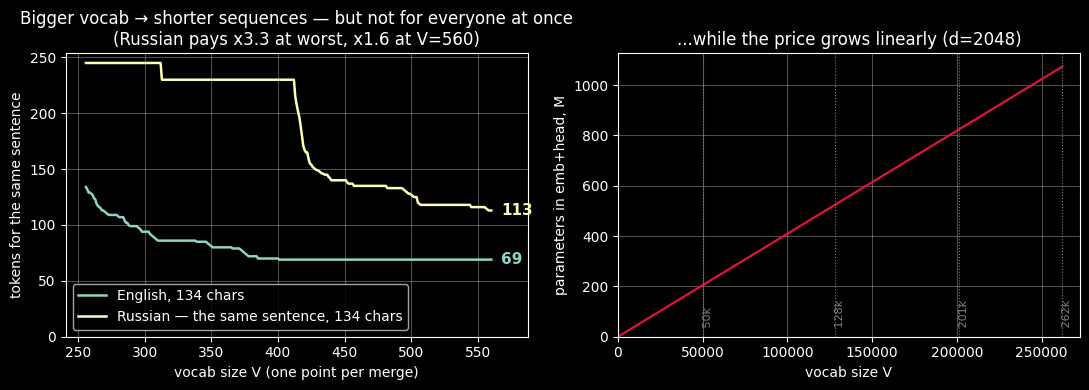

→ out\02_bpe_tradeoff.png

The gap between the two curves IS the tokenizer tax, and it is never zero.

Both sentences are 134 characters long, so nothing below is a length effect.

At V=256 there is no tokenizer yet, just bytes: 134 tokens against 245 for the same
sentence, x1.83 — and that part is pure UTF-8, paid before BPE ever runs.

Then English falls fast and Russian does not move at all: at V=401 it is
69 against 230, x3.3. The corpus is mostly English, so the most frequent pair is
almost always a Latin one, and every merge is spent on English until it has been squeezed dry.
Only after that do Cyrillic pairs start winning, and Russian drops to 113 — x1.64.

So the tax is not a property of the language. It is a property of the share the language had
in the training mix, and of the order in which merges get bought.



In [147]:
import matplotlib.pyplot as plt

full = BPE()
full.train(CORPUS, vocab_size=256 + 4000)
MAX_MERGES = len(full.merges)
print(f"corpus {len(CORPUS.encode('utf-8')):,} bytes → BPE runs out of repeating pairs "
      f"after {MAX_MERGES} merges (V = {256 + MAX_MERGES}).")
print("A production tokenizer is trained on hundreds of GB; V=200k there is a choice,\n"
      "here it would simply be unreachable. Vocabulary size is bounded by the corpus.\n")


def truncated(k: int) -> BPE:
    """The tokenizer training would have produced had it stopped after k merges.

    BPE rules are nested, and `encode` applies them strictly in the order they were
    learned — so the first k rules ARE the smaller tokenizer. That turns one point per
    merge into a dict slice instead of a full retraining, and lets us draw every single
    merge count instead of eight sampled ones."""
    t = BPE(use_regex=full.use_regex)
    t.merges = {pair: i for pair, i in full.merges.items() if i < 256 + k}
    t.vocab = {i: b for i, b in full.vocab.items() if i < 256 + k}
    return t


for k in (0, MAX_MERGES // 3, MAX_MERGES):      # the shortcut above is worth checking
    ref = BPE()
    if k:
        ref.train(CORPUS, vocab_size=256 + k)
    assert ref.encode(EN_TEST) == truncated(k).encode(EN_TEST), f"prefix != retrained, k={k}"
    assert ref.encode(RU_TEST) == truncated(k).encode(RU_TEST), f"prefix != retrained, k={k}"

sizes = list(range(MAX_MERGES + 1))
tok_en = [len(truncated(k).encode(EN_TEST)) for k in sizes]
tok_ru = [len(truncated(k).encode(RU_TEST)) for k in sizes]
ratio = [r / e for e, r in zip(tok_en, tok_ru)]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
V = [256 + k for k in sizes]
for series, label in ((tok_en, "English"), (tok_ru, "Russian — the same sentence")):
    (line,) = ax[0].plot(V, series, "-", lw=1.8,
                         label=f"{label}, {len(EN_TEST)} chars")
    ax[0].annotate(f"{series[-1]}", xy=(V[-1], series[-1]), xytext=(7, 0),
                   textcoords="offset points", va="center", fontsize=11,
                   fontweight="bold", color=line.get_color())
ax[0].set_xlabel("vocab size V (one point per merge)")
ax[0].set_ylabel("tokens for the same sentence")
ax[0].set_ylim(bottom=0)
ax[0].set_xlim(right=V[-1] + .09 * (V[-1] - V[0]))   # room for the end labels
ax[0].set_title(f"Bigger vocab → shorter sequences — but not for everyone at once\n"
                f"(Russian pays x{max(ratio):.1f} at worst, x{ratio[-1]:.1f} at V={256 + MAX_MERGES})")
ax[0].legend(); ax[0].grid(alpha=.3)

d = 2048
V_MAX = 262144
# Linear x on purpose: this is 2*V*d, a straight line through the origin. A log axis
# would bend it into something that looks exponential, contradicting the title.
V = list(range(0, V_MAX + 1, 4096))
ax[1].plot(V, [2 * v * d / 1e6 for v in V], "-", color="crimson", lw=1.6)
ax[1].set_xlabel("vocab size V")
ax[1].set_ylabel("parameters in emb+head, M")
ax[1].set_title(f"...while the price grows linearly (d={d})")
ax[1].set_xlim(0, V_MAX * 1.04); ax[1].set_ylim(bottom=0)
ax[1].grid(alpha=.3)
for v in (50257, 128256, 201088, 262144):
    ax[1].axvline(v, ls=":", c="gray", lw=.8)
    ax[1].text(v, 2 * V_MAX * d / 1e6 * .03, f" {v // 1000}k",
               rotation=90, fontsize=8, color="gray")

fig.tight_layout()
fig.savefig(OUT / "02_bpe_tradeoff.png", dpi=140)
plt.show()
print(f"→ {OUT / '02_bpe_tradeoff.png'}")

worst = ratio.index(max(ratio))
print(f"""
The gap between the two curves IS the tokenizer tax, and it is never zero.

Both sentences are {len(EN_TEST)} characters long, so nothing below is a length effect.

At V=256 there is no tokenizer yet, just bytes: {tok_en[0]} tokens against {tok_ru[0]} for the same
sentence, x{ratio[0]:.2f} — and that part is pure UTF-8, paid before BPE ever runs.

Then English falls fast and Russian does not move at all: at V={256 + sizes[worst]} it is
{tok_en[worst]} against {tok_ru[worst]}, x{max(ratio):.1f}. The corpus is mostly English, so the most frequent pair is
almost always a Latin one, and every merge is spent on English until it has been squeezed dry.
Only after that do Cyrillic pairs start winning, and Russian drops to {tok_ru[-1]} — x{ratio[-1]:.2f}.

So the tax is not a property of the language. It is a property of the share the language had
in the training mix, and of the order in which merges get bought.
""")

## Sanity check: round-trip
`decode(encode(x)) == x` for any text, including emoji and languages that were not in the
corpus. That is the byte-level property: **OOV is impossible by construction**.

The property holds only if the pre-tokenization regex covers every character. A character
no branch matches is not "encoded badly", it is dropped before the tokenizer ever sees it —
so the sweep below matters more than the hand-picked probes. It is there because `_` used
to fall through exactly that gap, and four hand-picked probes did not notice.

In [148]:
for probe in ["Совершенно новый текст 🚀", "日本語のテキスト", "def f(x): return x**2",
              "snake_case __init__ _", ""]:
    assert big.decode(big.encode(probe)) == probe, probe
    print(f"  ok  {len(big.encode(probe)):>3} tokens  {probe!r}")

uncovered = [chr(c) for c in range(32, 127)
             if "".join(BPE.SPLIT_PAT.findall(chr(c))) != chr(c)]
assert not uncovered, f"the regex drops these characters: {uncovered}"
print(f"  ok  every printable ASCII character survives pre-tokenization")
print("\nOOV does not exist: the worst case is a fallback to individual bytes.")

  ok   28 tokens  'Совершенно новый текст 🚀'
  ok   24 tokens  '日本語のテキスト'
  ok   18 tokens  'def f(x): return x**2'
  ok   19 tokens  'snake_case __init__ _'
  ok    0 tokens  ''
  ok  every printable ASCII character survives pre-tokenization

OOV does not exist: the worst case is a fallback to individual bytes.


## Where to go further with BPE
* Full reference implementation with tests: [minbpe](https://github.com/karpathy/minbpe) (Karpathy)
* A 2-hour video walkthrough: [Let's build the GPT Tokenizer](https://www.youtube.com/watch?v=zduSFxRajkE)
* Not covered here: WordPiece, Unigram/SentencePiece, measuring fertility on your own
  domain, training a tokenizer for one specific language.

---

# 03 — Attention from scratch: every decision checked by an experiment

**Lecture 1, block 3.** We do not retell the formula. We take it apart and watch what
breaks when a piece is missing.

| Part of the formula | What breaks without it | Section |
|---|---|---|
| `/ sqrt(d_k)` | softmax saturates, the gradient vanishes | §2 |
| mask before softmax | the future leaks → loss ≈ 0, generation is garbage | §3 |
| multiple heads | one head = one relation per layer | §4 |

Dependencies: only `torch` + `matplotlib`.

In [149]:
from __future__ import annotations

import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)
torch.manual_seed(0)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEV}")

device: cpu


## 1. Scaled dot-product attention

The three roles: **Q = what I am looking for, K = the key under which
I can be found, V = what I hand over to whoever found me.**

In [150]:
def attention(q, k, v, mask=None, scale=None):
    """q,k: (..., n, d_k);  v: (..., n, d_v);  mask: (n, n) bool, True = allowed."""
    d_k = q.size(-1)
    scores = q @ k.transpose(-2, -1)              # (..., n_q, n_k) — "how similar query i is to key j"
    scores = scores * (scale if scale is not None else d_k ** -0.5)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    w = scores.softmax(dim=-1)                    # rows sum to 1 → "how much attention"
    return w @ v, w                               # weighted sum of the values


n, d = 6, 16
q, k, v = torch.randn(3, n, d).unbind(0)
out, w = attention(q, k, v)
print(f"out {tuple(out.shape)}, weights {tuple(w.shape)}, row sum = {w.sum(-1)[0]:.4f}")

out (6, 16), weights (6, 6), row sum = 1.0000


## 2. Why `/ sqrt(d_k)` — measured, not taken on faith

q·k is a sum of d_k products of independent quantities ⇒ the variance grows like d_k,
the standard deviation like √d_k. Without the division, at d_k=128 the logits drift to ±30,
softmax becomes nearly one-hot, and **the gradient dies at every inactive position**.

In [151]:
def softmax_health(scores):
    """logit std, mean softmax maximum, entropy, mean Jacobian diagonal p(1-p)."""
    p = scores.softmax(-1)
    ent = -(p * (p + 1e-12).log()).sum(-1).mean().item()
    return (scores.std().item(), p.max(-1).values.mean().item(), ent, (p * (1 - p)).mean().item())


print(f"{'':>6}{'no 1/√d_k':^38}|{'with 1/√d_k':^38}")
cols = f"{'std':>9}{'max p':>9}{'entr.':>9}{'p(1-p)':>11}"
print(f"{'d_k':>6}{cols}|{cols}")
print("-" * 82)
for d_k in [8, 32, 128, 512, 2048]:
    qq, kk = torch.randn(1024, d_k), torch.randn(1024, d_k)
    raw = softmax_health(qq @ kk.T)
    sc = softmax_health((qq @ kk.T) * d_k ** -0.5)
    fmt = lambda t: f"{t[0]:>9.2f}{t[1]:>9.3f}{t[2]:>9.2f}{t[3]:>11.1e}"
    print(f"{d_k:>6}{fmt(raw)}|{fmt(sc)}")

print("""
Read the left half: as d_k grows the logit std grows like √d_k, the softmax maximum → 1,
the entropy → 0, and most importantly the mean softmax Jacobian diagonal p(1-p) drops by
an order of magnitude. That is "the gradient died": the layer stops learning because softmax
is already confident — on PURELY RANDOM numbers, before any training. The right half: with
1/√d_k everything is invariant to d_k, which is exactly what we wanted.
""")

                    no 1/√d_k               |             with 1/√d_k              
   d_k      std    max p    entr.     p(1-p)|      std    max p    entr.     p(1-p)
----------------------------------------------------------------------------------
     8     2.87    0.229     3.87    8.7e-04|     1.01    0.018     6.42    9.7e-04
    32     5.64    0.575     1.52    5.5e-04|     1.00    0.016     6.44    9.7e-04
   128    11.32    0.787     0.61    2.9e-04|     1.00    0.016     6.43    9.7e-04
   512    22.61    0.901     0.26    1.4e-04|     1.00    0.016     6.43    9.7e-04
  2048    45.26    0.954     0.11    6.4e-05|     1.00    0.016     6.43    9.7e-04

Read the left half: as d_k grows the logit std grows like √d_k, the softmax maximum → 1,
the entropy → 0, and most importantly the mean softmax Jacobian diagonal p(1-p) drops by
an order of magnitude. That is "the gradient died": the layer stops learning because softmax
is already confident — on PURELY RANDOM numbers, before a

## 3. The causal mask: three ways, two of which coincide

The classic starred question: "why is the mask applied BEFORE softmax and not after?".
The honest answer: zeroing after softmax and **renormalizing** is mathematically the same.
The variant that actually breaks is "zero out and do not renormalize".

In [152]:
mask = torch.tril(torch.ones(n, n, dtype=torch.bool))

s = (q @ k.T) * d ** -0.5
a_before = s.masked_fill(~mask, float("-inf")).softmax(-1)      # the correct path
p = s.softmax(-1)
a_after_bad = p * mask                                          # zeroed out, that is all
a_after_ok = a_after_bad / a_after_bad.sum(-1, keepdim=True)    # zeroed out + renormalized

print(f"|before − after+renorm| = {(a_before - a_after_ok).abs().max():.2e}   ← identical")
print(f"|before − after(no renorm)| = {(a_before - a_after_bad).abs().max():.2e}  ← not")
print(f"row sums without renormalization: {a_after_bad.sum(-1).tolist()}")
print("""
So why -inf before softmax after all?
  1. No second pass over the row is needed for normalization.
  2. Numerically: exp() of -inf is exactly 0, not "a small number we then divide by".
  3. Most importantly — this is how fused attention kernels work: the score matrix
     is never materialized at all, the mask is applied on the fly inside the tile.
""")

|before − after+renorm| = 5.96e-08   ← identical
|before − after(no renorm)| = 9.69e-01  ← not
row sums without renormalization: [0.031210776418447495, 0.6020203232765198, 0.324299156665802, 0.5610283613204956, 0.9591208696365356, 1.0]

So why -inf before softmax after all?
  1. No second pass over the row is needed for normalization.
  2. Numerically: exp() of -inf is exactly 0, not "a small number we then divide by".
  3. Most importantly — this is how fused attention kernels work: the score matrix
     is never materialized at all, the mask is applied on the fly inside the tile.



### And the most vivid part — what happens if you forget the mask
The model sees the answer. The loss drops to nearly zero within a dozen steps, and generation
is garbage. We show it on a "predict the next token" task over a random sequence.

In [153]:
class TinyLM(torch.nn.Module):
    def __init__(self, V=32, d=64, causal=True):
        super().__init__()
        self.emb = torch.nn.Embedding(V, d)
        self.pos = torch.nn.Embedding(64, d)
        self.qkv = torch.nn.Linear(d, 3 * d)
        self.head = torch.nn.Linear(d, V)
        self.causal = causal

    def forward(self, x):
        n = x.size(1)
        h = self.emb(x) + self.pos(torch.arange(n, device=x.device))
        qq, kk, vv = self.qkv(h).chunk(3, dim=-1)
        m = torch.tril(torch.ones(n, n, dtype=torch.bool, device=x.device)) if self.causal else None
        a, _ = attention(qq, kk, vv, mask=m)
        return self.head(h + a)


V, T = 32, 32
# The data is uniform noise. This is not "for lack of anything better" but a deliberate choice:
# the tokens are independent, so the true p(x_t | x_<t) = 1/V at ANY position, and the optimal
# achievable loss is known EXACTLY — ln V = 3.466. A Bayes limit, not an empirical estimate.
# Real text offers no such reference point, and a low loss can always be waved away as
# "the model simply learned the language well".
#
# The dataset size was picked empirically: with 64 sequences the causal model memorized the
# sample outright (train 0.73 vs test 22.97) and the picture got muddy; at 512 there is no
# memorization left. Comparing "number of parameters against number of targets" is meaningless
# here — memorization capacity does not equal the parameter count
# (the model has 20.7k of them against 16k targets, and still does not memorize).
train = torch.randint(0, V, (512, T + 1))
test = torch.randint(0, V, (512, T + 1))  # fresh noise: learning it is impossible in principle


def run_epoch(m, batch):
    logits = m(batch[:, :-1])
    return F.cross_entropy(logits.reshape(-1, V), batch[:, 1:].reshape(-1))


print(f"{'mask':<10}{'train loss':>12}{'TEST loss':>12}"
      f"   (optimum = ln {V} = {math.log(V):.2f})")
print("-" * 40)
for causal in (True, False):
    torch.manual_seed(0)
    m = TinyLM(V, causal=causal)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-3)
    for _ in range(300):
        loss = run_epoch(m, train)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        te = run_epoch(m, test).item()
    print(f"{'yes' if causal else 'NO':<10}{loss.item():>12.4f}{te:>12.4f}")

print("""
Look at TEST, and the reference here is not "lower is better" but an EXACT number: ln V = 3.466.
That is the optimum, below which there is no honest way to go.

With the mask the model stays close to it (slightly above — it has fitted the training set a
little, and pays for that on fresh noise). This is the CORRECT behaviour: noise cannot be learned.
Without the mask it reaches a near-zero loss on both train and test. Such a value cannot be
obtained legitimately, which means the model is not learning but copying the answer that is
sitting right there in its input.

Practical takeaway: an anomalously low pretraining loss is almost always a leak, not a brilliant
architecture. Check in this order: the mask, the target shift by 1, padding/document packing,
duplicates between train and eval.
""")

mask        train loss   TEST loss   (optimum = ln 32 = 3.47)
----------------------------------------
yes             3.0678      3.9895
NO              0.0455      0.2222

Look at TEST, and the reference here is not "lower is better" but an EXACT number: ln V = 3.466.
That is the optimum, below which there is no honest way to go.

With the mask the model stays close to it (slightly above — it has fitted the training set a
little, and pays for that on fresh noise). This is the CORRECT behaviour: noise cannot be learned.
Without the mask it reaches a near-zero loss on both train and test. Such a value cannot be
obtained legitimately, which means the model is not learning but copying the answer that is
sitting right there in its input.

Practical takeaway: an anomalously low pretraining loss is almost always a leak, not a brilliant
architecture. Check in this order: the mask, the target shift by 1, padding/document packing,
duplicates between train and eval.



## 4. Multi-head: the reshape mechanics and a check against the reference

Heads are not about parallelism but about the fact that one head = **one** relation of
"who looks at whom". A syntactic dependency and an induction pattern do not fit into
a single softmax row.

In [154]:
class MHA(torch.nn.Module):
    def __init__(self, d_model, n_heads, causal=True):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dh, self.causal = n_heads, d_model // n_heads, causal
        self.qkv = torch.nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = torch.nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, use_sdpa=False):
        B, T, C = x.shape
        # (B,T,3C) → 3 × (B, h, T, dh):  a head is a slice of the channel, not a separate matrix
        qkv = self.qkv(x).view(B, T, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        qq, kk, vv = qkv.unbind(0)
        if use_sdpa:
            y = F.scaled_dot_product_attention(qq, kk, vv, is_causal=self.causal)
            w = None
        else:
            m = torch.tril(torch.ones(T, T, dtype=torch.bool, device=x.device)) if self.causal else None
            y, w = attention(qq, kk, vv, mask=m)
        y = y.transpose(1, 2).reshape(B, T, C)      # concat the heads back into the channel
        return self.proj(y), w


x = torch.randn(2, 24, 128)
mha = MHA(128, 8)
y_naive, w = mha(x, use_sdpa=False)
y_fast, _ = mha(x, use_sdpa=True)
print(f"our implementation vs F.scaled_dot_product_attention: "
      f"max |Δ| = {(y_naive - y_fast).abs().max():.2e}   (should be ~1e-6)")
print(f"attention weights: {tuple(w.shape)}  = (batch, heads, queries, keys)")

print("""
One reshape, and that is all. Which gives an important consequence: d_head = d_model / n_heads,
so at a fixed d_model more heads ⇒ each one is "narrower". Llama-3-8B: d=4096, h=32, d_head=128;
that is exactly the constant 128 that has stuck almost everywhere (convenient for kernels).
""")

our implementation vs F.scaled_dot_product_attention: max |Δ| = 1.79e-07   (should be ~1e-6)
attention weights: (2, 8, 24, 24)  = (batch, heads, queries, keys)

One reshape, and that is all. Which gives an important consequence: d_head = d_model / n_heads,
so at a fixed d_model more heads ⇒ each one is "narrower". Llama-3-8B: d=4096, h=32, d_head=128;
that is exactly the constant 128 that has stuck almost everywhere (convenient for kernels).



## 5. The two costs of attention — measured

O(n²·d) in compute and O(n²) in memory for the score matrix.
The second one is what fused kernels avoid: the matrix is never materialized.

Two different kinds of number below, and it matters which is which:
the times are **measured** on whatever machine this runs on, the memory is **computed**
from the tensor shapes. Nothing here allocates a score matrix to weigh it — the weight
of a tensor of known shape and dtype is exact arithmetic, and measuring it would add
noise rather than truth. What is NOT checked here is the next step — that a real fused
kernel does not pay that memory. That one is stated, not demonstrated.

     T    naive, ms   SDPA, ms  speedup   naive x   SDPA x     score matrix
----------------------------------------------------------------------------
   128         0.48       0.31     1.5x         —        —           0.5 MB
   256         1.51       0.92     1.6x      3.1x     2.9x           2.0 MB
   512         6.48       2.96     2.2x      4.3x     3.2x           8.0 MB
  1024        23.14       9.86     2.3x      3.6x     3.3x          32.0 MB
  2048        87.78      30.65     2.9x      3.8x     3.1x         128.0 MB

Every doubling of T costs 3.1-4.3x more time; linear growth would be 2x,
quadratic 4x. Least-squares fit over the range: naive n^1.89, SDPA n^1.66.

The arithmetic is exactly quadratic: 4·B·H·T²·d_head FLOPs. The measured exponent is below 2
because the constant is still falling — a CPU uses cache and threads better on bigger matmuls,
so each doubling of T buys some efficiency back. It reaches 2 only at lengths a CPU cannot
reach here.

SDPA and the naive versio

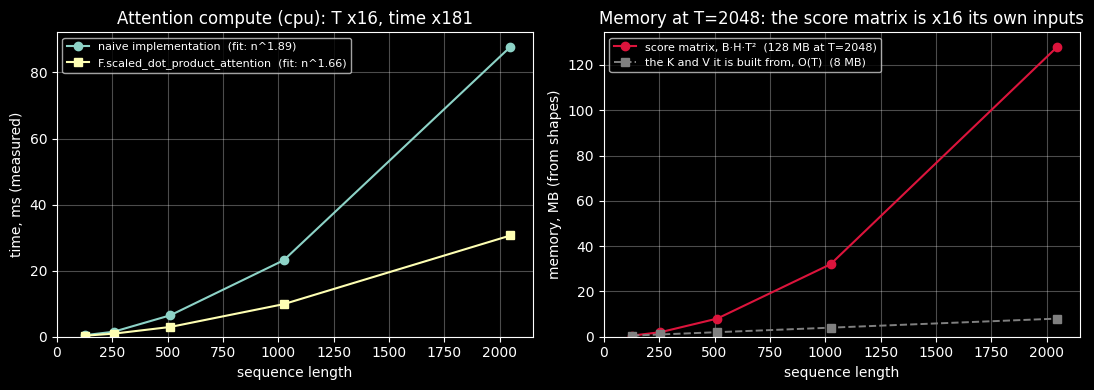


→ out\03_attention_cost.png

⚠ These are absolute numbers for THIS machine. What carries over is the shape of the curves
and the ratio between them, not the milliseconds.

Two axes of cost, one picture. Left: compute, O(n²·d), paid on every training step —
timed here. Right: memory — NOT timed, computed from the shapes: B·H·T² floats for the score
matrix against 2·B·H·T·d_head for K and V. The two curves start at the same point and end a
factor of 16 apart, because one grows as T² and the other as T. The grey one is the
whole input to the operation; the red one is a temporary built out of it.

That gap is why production kernels compute attention in tiles: the output only ever needs
one block of the score matrix at a time, so the full matrix never has to exist. The FLOPs
stay exactly the same, the memory does not. At T=32k with 32 heads the full matrix would
be ~128 GB, which nobody has.



In [155]:
Bs, H_, Dh = 1, 8, 64
lens = [128, 256, 512, 1024, 2048]
t_naive, t_sdpa, mem_scores, mem_kv = [], [], [], []


def timeit(fn, budget_ms=60, rounds=3):
    """Milliseconds per call, measured so that the exponent below means something.

    Three things matter and all three were missing from the obvious version:
    a warm-up call (the first one pays for allocation and thread start-up);
    a rep count chosen from a trial call, so a 0.5 ms case is not timed once;
    and the MINIMUM over several rounds — anything else running on the machine
    can only ADD time, so the minimum is the honest estimate, the mean is not."""
    def sync():
        if DEV == "cuda":
            torch.cuda.synchronize()

    fn(); sync()
    t0 = time.perf_counter(); fn(); sync()
    one_ms = (time.perf_counter() - t0) * 1e3
    reps = max(3, min(200, int(budget_ms / max(one_ms, 1e-3))))
    best = float("inf")
    for _ in range(rounds):
        t0 = time.perf_counter()
        for _ in range(reps):
            fn()
        sync()
        best = min(best, (time.perf_counter() - t0) / reps * 1e3)
    return best


for T in lens:
    qq, kk, vv = [torch.randn(Bs, H_, T, Dh, device=DEV) for _ in range(3)]
    m = torch.tril(torch.ones(T, T, dtype=torch.bool, device=DEV))
    t_naive.append(timeit(lambda: attention(qq, kk, vv, mask=m)))
    t_sdpa.append(timeit(lambda: F.scaled_dot_product_attention(qq, kk, vv, is_causal=True)))
    mem_scores.append(Bs * H_ * T * T * 4 / 2 ** 20)        # fp32 score matrix, MB
    mem_kv.append(2 * Bs * H_ * T * Dh * 4 / 2 ** 20)       # the K and V it is built from


def exponent(xs, ys):
    """Least-squares slope of log(y) against log(x) — the measured k in t ~ n^k."""
    lx, ly = [math.log(x) for x in xs], [math.log(y) for y in ys]
    mx, my = sum(lx) / len(lx), sum(ly) / len(ly)
    return sum((a - mx) * (b - my) for a, b in zip(lx, ly)) / sum((a - mx) ** 2 for a in lx)


k_naive, k_sdpa = exponent(lens, t_naive), exponent(lens, t_sdpa)

print(f"{'T':>6}{'naive, ms':>13}{'SDPA, ms':>11}{'speedup':>9}"
      f"{'naive x':>10}{'SDPA x':>9}{'score matrix':>17}")
print("-" * 76)
for i, T in enumerate(lens):
    gn = f"{t_naive[i] / t_naive[i - 1]:.1f}x" if i else "—"
    gs = f"{t_sdpa[i] / t_sdpa[i - 1]:.1f}x" if i else "—"
    print(f"{T:>6}{t_naive[i]:>13.2f}{t_sdpa[i]:>11.2f}{t_naive[i] / t_sdpa[i]:>8.1f}x"
          f"{gn:>10}{gs:>9}{mem_scores[i]:>14.1f} MB")
growth = [t_naive[i] / t_naive[i - 1] for i in range(1, len(lens))]
print(f"""
Every doubling of T costs {min(growth):.1f}-{max(growth):.1f}x more time; linear growth would be 2x,
quadratic 4x. Least-squares fit over the range: naive n^{k_naive:.2f}, SDPA n^{k_sdpa:.2f}.

The arithmetic is exactly quadratic: 4·B·H·T²·d_head FLOPs. The measured exponent is below 2
because the constant is still falling — a CPU uses cache and threads better on bigger matmuls,
so each doubling of T buys some efficiency back. It reaches 2 only at lengths a CPU cannot
reach here.

SDPA and the naive version grow at the same rate; SDPA is a constant factor below.
The fused path removes no FLOPs — it saves memory traffic, and wins time through that.
""")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# Linear axes on purpose. On log-log a power law is a straight line, so n² and n look
# equally straight and the curvature — the thing we are actually teaching — is invisible.
ax[0].plot(lens, t_naive, "o-", label=f"naive implementation  (fit: n^{k_naive:.2f})")
ax[0].plot(lens, t_sdpa, "s-", label=f"F.scaled_dot_product_attention  (fit: n^{k_sdpa:.2f})")
ax[0].set_xlabel("sequence length"); ax[0].set_ylabel("time, ms (measured)")
ax[0].set_xlim(0, lens[-1] * 1.05); ax[0].set_ylim(bottom=0)
ax[0].set_title(f"Attention compute ({DEV}): T x{lens[-1] // lens[0]}, time x{t_naive[-1] / t_naive[0]:.0f}")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# Same linear axes as the left panel, and for the same reason: the point is that one
# of these two curves bends and the other does not.
ax[1].plot(lens, mem_scores, "o-", color="crimson",
           label=f"score matrix, B·H·T²  ({mem_scores[-1]:.0f} MB at T={lens[-1]})")
ax[1].plot(lens, mem_kv, "s--", color="gray", lw=1.4,
           label=f"the K and V it is built from, O(T)  ({mem_kv[-1]:.0f} MB)")
ax[1].set_xlabel("sequence length"); ax[1].set_ylabel("memory, MB (from shapes)")
ax[1].set_xlim(0, lens[-1] * 1.05); ax[1].set_ylim(bottom=0)
ax[1].set_title(f"Memory at T={lens[-1]}: the score matrix is "
                f"x{mem_scores[-1] / mem_kv[-1]:.0f} its own inputs")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "03_attention_cost.png", dpi=140)
plt.show()
print(f"\n→ {OUT / '03_attention_cost.png'}")

factor = mem_scores[-1] / mem_kv[-1]
print(f"""
⚠ These are absolute numbers for THIS machine. What carries over is the shape of the curves
and the ratio between them, not the milliseconds.

Two axes of cost, one picture. Left: compute, O(n²·d), paid on every training step —
timed here. Right: memory — NOT timed, computed from the shapes: B·H·T² floats for the score
matrix against 2·B·H·T·d_head for K and V. The two curves start at the same point and end a
factor of {factor:.0f} apart, because one grows as T² and the other as T. The grey one is the
whole input to the operation; the red one is a temporary built out of it.

That gap is why production kernels compute attention in tiles: the output only ever needs
one block of the score matrix at a time, so the full matrix never has to exist. The FLOPs
stay exactly the same, the memory does not. At T=32k with 32 heads the full matrix would
be ~128 GB, which nobody has.
""")

## Takeaways: attention
* `/√d_k` is not cosmetic: without it softmax saturates and the gradient vanishes (§2).
* Masking before softmax is about numerics and fused kernels; the catastrophe is forgetting
  it entirely (§3).
* A head = one relation; d_head = d/h ≈ 128 almost everywhere (§4).
* O(n²) in compute is unavoidable, O(n²) in memory is not (§5).

**Next:** RoPE (positions), the KV cache (the second cost axis),
GQA (how that axis is treated).

---

# 04 — Attention in 3D: looking at the whole attention tensor at once

**Lecture 1, block 3.**

An ordinary heatmap shows ONE head of ONE layer. But attention is a tensor
`(layer, head, query, key)`, and the interesting part starts when all slices are visible at once.
We build four views:

| View | What it shows | File |
|---|---|---|
| **attention cube** | (key × query × layer) — a volume render, you can see the "focus" migrate with depth | `out/04_attn_cube.html` |
| **head landscape** | one head as a 3D surface: peaks = "who looks at whom" | `out/04_attn_surface.html` |
| **head atlas** | a layer×head grid of mini-maps — the zoo of patterns at a glance | `out/04_attn_atlas.html` |
| **Q/K space** | PCA of queries and keys in 3D (in the spirit of AttentionViz) — clusters of "locks and keys" | `out/04_attn_qk_space.html` |

```bash
pip install plotly            # required
pip install transformers      # optional: a real GPT-2 instead of synthetic data
```
Without `transformers` the script works on a **synthetic** tensor with predefined head types —
that is useful too: you first see the "reference" patterns in pure form,
and then look for them in a real model.

In [156]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    sys.exit("plotly required:  pip install plotly")

OUT = Path("out")
OUT.mkdir(exist_ok=True)

# "cdn" — files of ~20 KB, but you need internet access when opening them;
# True — plotly.js is inlined (~3.5 MB per file), works offline.
# If the HTML has to open without internet: flip this to True and rerun.
PLOTLYJS = "cdn"

DEMO_TEXT = ("The cat sat on the mat. The cat sat on the")

## Data source

We return `attn` of shape `(L, H, T, T)`, the token list and (if available) Q/K.

In [157]:
def causal_normalize(a: np.ndarray) -> np.ndarray:
    """Zero out the future and renormalize the rows — what softmax with a mask does."""
    T = a.shape[-1]
    m = np.tril(np.ones((T, T)))
    a = a * m
    return a / np.clip(a.sum(-1, keepdims=True), 1e-9, None)


def synthetic_attention(tokens: list[str], n_layers=12, n_heads=12, seed=0):
    """A synthetic attention tensor with KNOWN head types.

    This is a "pure culture" of the patterns that are mixed together in a real model.
    The order of types across layers roughly repeats what is visible in GPT-2:
    early layers — local/previous-token, middle — induction, late — sink + broad.
    """
    rng = np.random.default_rng(seed)
    T = len(tokens)
    i = np.arange(T)[:, None]
    j = np.arange(T)[None, :]

    def prev_token():                       # looks strictly at the previous token
        return np.exp(-((i - j - 1) ** 2) / 0.3) + 1e-3

    def local(tau=2.0):                     # sliding window
        return np.exp(-(i - j) / tau) * (j <= i) + 1e-3

    def sink():                             # nearly all attention on the first token
        a = np.full((T, T), 1e-3)
        a[:, 0] = 1.0
        return a

    def induction():                        # "where have I seen this? → what came AFTER"
        a = np.full((T, T), 1e-3)
        for qi in range(T):
            for kj in range(1, qi):
                if tokens[kj - 1] == tokens[qi]:      # the previous token matched the current one
                    a[qi, kj] = 1.0
        return a

    def diffuse():                          # uniformly over the past
        return np.ones((T, T))

    def content(word=".",):                 # reaches for a specific token (punctuation)
        a = np.full((T, T), 1e-3)
        for kj, t in enumerate(tokens):
            if t.strip() == word:
                a[:, kj] = 1.0
        return a

    zoo = [prev_token, local, sink, induction, diffuse, content]
    attn = np.zeros((n_layers, n_heads, T, T))
    for l in range(n_layers):
        # the layer's "recipe" weights: early layers local, middle induction, late sink
        depth = l / max(n_layers - 1, 1)
        mix = np.array([
            1.5 * (1 - depth),          # prev_token
            1.2 * (1 - depth) + 0.2,    # local
            0.2 + 1.5 * depth,          # sink
            1.6 * np.exp(-((depth - 0.45) ** 2) / 0.02),   # induction — peaks in the middle
            0.3 + 0.6 * depth,          # diffuse
            0.4,                        # content
        ])
        for h in range(n_heads):
            w = rng.dirichlet(mix * 2 + 0.05)
            a = sum(wi * f() for wi, f in zip(w, zoo))
            a = a * (0.8 + 0.4 * rng.random((T, T)))       # noise
            attn[l, h] = causal_normalize(a)

    d_head = 64
    Q = rng.normal(size=(n_layers, n_heads, T, d_head))
    K = rng.normal(size=(n_layers, n_heads, T, d_head))
    return attn, tokens, Q, K


def gpt2_attention(text: str, model_name="gpt2"):
    """Real GPT-2 attention + Q and K pulled out with hooks."""
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name, attn_implementation="eager")
    model.eval()

    ids = tok(text, return_tensors="pt")
    tokens = [tok.decode([i]) for i in ids["input_ids"][0]]

    qs, ks = [], []

    def hook(mod, inp, out):
        # in GPT-2 the Conv1D c_attn returns [q|k|v] as a single tensor
        q, k, _ = out.split(mod.nf // 3, dim=-1)
        B, T, C = q.shape
        h = model.config.n_head
        qs.append(q.view(B, T, h, C // h).permute(0, 2, 1, 3)[0].detach().numpy())
        ks.append(k.view(B, T, h, C // h).permute(0, 2, 1, 3)[0].detach().numpy())

    handles = [blk.attn.c_attn.register_forward_hook(hook) for blk in model.transformer.h]
    with torch.no_grad():
        out = model(**ids, output_attentions=True)
    for hd in handles:
        hd.remove()

    attn = torch.stack(out.attentions).squeeze(1).numpy()   # (L, H, T, T)
    return attn, tokens, np.stack(qs), np.stack(ks)

In [158]:
# The knobs for this section — edit directly and rerun if you want a different
# source, model, or head.
SOURCE = "auto"                              # "auto" | "npz" | "gpt2" | "synthetic"
NPZ_PATH = OUT / "gpu_gpt2_attention.npz"    # a ready-made attention tensor captured on a GPU
MODEL = "gpt2"
LAYER = 5
HEAD = 5

src = SOURCE
if src == "auto":
    if NPZ_PATH.exists():
        src = "npz"                       # the best option: real data, nothing to download
    else:
        try:
            import transformers  # noqa: F401
            src = "gpt2"
        except ImportError:
            src = "synthetic"

if src == "npz":
    print(f"source: {NPZ_PATH} (tensor captured from a real GPT-2 on an H100)")
    d = np.load(NPZ_PATH, allow_pickle=True)
    attn, Q, K = d["attn"], d["Q"], d["K"]
    tokens = [str(t) for t in d["tokens"]]
elif src == "gpt2":
    print(f"source: {MODEL} (real attention)")
    attn, tokens, Q, K = gpt2_attention(DEMO_TEXT, MODEL)
else:
    print("source: synthetic (reference head patterns)")
    tokens = DEMO_TEXT.split()
    attn, tokens, Q, K = synthetic_attention(tokens)

print(f"attention tensor: {attn.shape} = (layers, heads, queries, keys)")
print(f"tokens: {tokens}\n")

source: out\gpu_gpt2_attention.npz (tensor captured from a real GPT-2 on an H100)
attention tensor: (12, 12, 12, 12) = (layers, heads, queries, keys)
tokens: ['The', ' cat', ' sat', ' on', ' the', ' mat', '.', ' The', ' cat', ' sat', ' on', ' the']



## View 1 — the attention cube

Axes: **x = key (what we look at), y = query (who looks), z = layer**.
Inside each layer we average over heads. The volume render shows how the "attention mass"
moves with depth: in early layers it sits along the diagonal (locality), in late ones
it slides toward the column j=0 (attention sink).

In [159]:
def cube(attn: np.ndarray, tokens: list[str], path: Path, per_head: int | None = None) -> None:
    a = attn.mean(1) if per_head is None else attn[:, per_head]   # (L, T, T)
    L, T, _ = a.shape
    Z, Y, X = np.mgrid[0:L, 0:T, 0:T]
    fig = go.Figure(go.Volume(
        x=X.ravel(), y=Y.ravel(), z=Z.ravel(),
        value=a.ravel() ** 0.5,                # square root — otherwise the sink eats everything
        isomin=0.08, isomax=float(np.sqrt(a.max())),
        opacity=0.12, surface_count=18, colorscale="Turbo",
        colorbar=dict(title="weight<sup>½</sup>"),
    ))
    fig.update_layout(
        title=f"Attention cube: {'averaged over heads' if per_head is None else f'head {per_head}'}"
              " — key × query × layer",
        scene=dict(
            xaxis=dict(title="key j (who is looked at)", tickmode="array",
                       tickvals=list(range(T)), ticktext=tokens),
            yaxis=dict(title="query i (who looks)", tickmode="array",
                       tickvals=list(range(T)), ticktext=tokens),
            zaxis=dict(title="layer"),
            camera=dict(eye=dict(x=1.7, y=-1.7, z=1.1)),
        ),
        margin=dict(l=0, r=0, t=44, b=0), height=760,
    )
    fig.write_html(path, include_plotlyjs=PLOTLYJS)
    print(f"→ {path}")

In [160]:
cube(attn, tokens, OUT / "04_attn_cube.html")
_show_html(OUT / "04_attn_cube.html", height=760)

→ out\04_attn_cube.html


## View 2 — the landscape of a single head

The same thing as a heatmap, but as relief: peaks read better than shades of colour,
and on a projector they are visible from the back row.

In [161]:
def surface(attn: np.ndarray, tokens: list[str], layer: int, head: int, path: Path) -> None:
    a = attn[layer, head]
    T = a.shape[0]
    fig = go.Figure(go.Surface(
        z=a, colorscale="Turbo", showscale=True,
        contours=dict(z=dict(show=True, usecolormap=True, project_z=True)),
        hovertemplate="query %{y}<br>key %{x}<br>weight %{z:.3f}<extra></extra>",
    ))
    fig.update_layout(
        title=f"Attention landscape — layer {layer}, head {head}",
        scene=dict(
            xaxis=dict(title="key j", tickmode="array", tickvals=list(range(T)), ticktext=tokens),
            yaxis=dict(title="query i", tickmode="array", tickvals=list(range(T)), ticktext=tokens),
            zaxis=dict(title="attention weight"),
            camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0)),
        ),
        margin=dict(l=0, r=0, t=44, b=0), height=720,
    )
    fig.write_html(path, include_plotlyjs=PLOTLYJS)
    print(f"→ {path}")

In [162]:
surface(attn, tokens, LAYER, HEAD, OUT / "04_attn_surface.html")
_show_html(OUT / "04_attn_surface.html", height=720)

→ out\04_attn_surface.html


## View 3 — the head atlas

A `layer × head` grid of mini-maps. What "heads specialize" means is visible here
without a single word of theory.

In [163]:
def atlas(attn: np.ndarray, path: Path, max_layers=12, max_heads=12) -> None:
    L = min(attn.shape[0], max_layers)
    H = min(attn.shape[1], max_heads)
    fig = make_subplots(
        rows=L, cols=H, horizontal_spacing=0.004, vertical_spacing=0.004,
        row_titles=[f"L{l}" for l in range(L)], column_titles=[f"H{h}" for h in range(H)],
    )
    for l in range(L):
        for h in range(H):
            fig.add_trace(
                go.Heatmap(z=attn[l, h] ** 0.5, colorscale="Turbo", showscale=False,
                           hovertemplate=f"L{l}H{h}<br>q %{{y}} → k %{{x}}<br>%{{z:.2f}}<extra></extra>"),
                row=l + 1, col=h + 1,
            )
    fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False)
    fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False, autorange="reversed")
    fig.update_layout(title="Head atlas: every cell is its own attention matrix",
                      height=110 * L, width=110 * H, margin=dict(l=40, r=40, t=60, b=20))
    fig.write_html(path, include_plotlyjs=PLOTLYJS)
    print(f"→ {path}")

In [164]:
atlas(attn, OUT / "04_attn_atlas.html")
_show_html(OUT / "04_attn_atlas.html", height=1320)

→ out\04_attn_atlas.html


## View 4 — the space of queries and keys

The idea of [AttentionViz](https://attentionviz.com): instead of the weight matrix, look at
**the vectors themselves**, Q and K, in a shared space. Attention is a dot product, so
"who will look at whom" = "who ended up close to whom in direction".
Clusters where Q and K are mixed together are precisely the learned "locks and keys".

In [165]:
def qk_space(Q: np.ndarray, K: np.ndarray, tokens: list[str], layer: int, head: int,
             path: Path) -> None:
    q, k = Q[layer, head], K[layer, head]            # (T, d_head)
    X = np.concatenate([q, k], 0)
    X = X - X.mean(0)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)  # PCA without sklearn
    P = X @ Vt[:3].T
    T = len(tokens)
    var = (S[:3] ** 2).sum() / (S ** 2).sum()

    fig = go.Figure()
    for name, sl, sym, col in [("queries (who searches)", slice(0, T), "circle", "#e45756"),
                               ("keys (who is found)", slice(T, 2 * T), "diamond", "#4c78a8")]:
        fig.add_trace(go.Scatter3d(
            x=P[sl, 0], y=P[sl, 1], z=P[sl, 2], mode="markers+text",
            text=tokens, textposition="top center", textfont=dict(size=9),
            marker=dict(size=6, symbol=sym, color=col, opacity=0.85), name=name,
        ))
    # connect every query to the key it selected most strongly
    a = (q @ k.T) / np.sqrt(q.shape[-1])
    a = np.where(np.tril(np.ones_like(a)) > 0, a, -np.inf)
    best = a.argmax(1)
    for i, j in enumerate(best):
        fig.add_trace(go.Scatter3d(
            x=[P[i, 0], P[T + j, 0]], y=[P[i, 1], P[T + j, 1]], z=[P[i, 2], P[T + j, 2]],
            mode="lines", line=dict(color="rgba(120,120,120,0.35)", width=2),
            showlegend=False, hoverinfo="skip",
        ))
    fig.update_layout(
        title=f"Q/K space, layer {layer} head {head} "
              f"(PCA, {var:.0%} of variance explained). Lines: query → its best key",
        margin=dict(l=0, r=0, t=44, b=0), height=760,
        scene=dict(camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0))),
    )
    fig.write_html(path, include_plotlyjs=PLOTLYJS)
    print(f"→ {path}")

In [166]:
qk_space(Q, K, tokens, LAYER, HEAD, OUT / "04_attn_qk_space.html")
_show_html(OUT / "04_attn_qk_space.html", height=760)

→ out\04_attn_qk_space.html


## Diagnostics: labelling the heads automatically

So that we do not point at cells at random, let us compute three numbers per head:
* **prev** — how much weight goes exactly to the previous token;
* **sink** — how much goes to position 0;
* **entropy** — how "spread out" the attention is.

These are precisely the metrics mech-interp uses to look for interesting heads.

In [167]:
def head_report(attn: np.ndarray, top=10) -> None:
    L, H, T, _ = attn.shape
    rows = []
    for l in range(L):
        for h in range(H):
            a = attn[l, h]
            prev = np.mean([a[i, i - 1] for i in range(1, T)])
            sink = a[1:, 0].mean()
            diag = np.mean([a[i, i] for i in range(T)])
            ent = float(np.mean(-(a * np.log(a + 1e-12)).sum(-1)))
            rows.append((l, h, prev, sink, diag, ent))
    print(f"\n{'':>7}{'prev':>8}{'sink':>8}{'self':>8}{'entropy':>11}")
    print("top 'previous token' heads:")
    for l, h, p, s, d, e in sorted(rows, key=lambda r: -r[2])[:top // 2]:
        print(f"  {f'L{l}H{h}':<8}{p:>8.2f}{s:>8.2f}{d:>8.2f}{e:>11.2f}")
    print("top 'attention sink' heads (everything on BOS):")
    for l, h, p, s, d, e in sorted(rows, key=lambda r: -r[3])[:top // 2]:
        print(f"  {f'L{l}H{h}':<8}{p:>8.2f}{s:>8.2f}{d:>8.2f}{e:>11.2f}")
    print("the most 'spread out' heads (high entropy ≈ averaging the context):")
    for l, h, p, s, d, e in sorted(rows, key=lambda r: -r[5])[:top // 2]:
        print(f"  {f'L{l}H{h}':<8}{p:>8.2f}{s:>8.2f}{d:>8.2f}{e:>11.2f}")

In [168]:
head_report(attn)

print("""
How to read these four views:
  1. 04_attn_atlas.html — the head zoo at a glance: here is the range of patterns heads learn.
  2. 04_attn_surface.html — one head as a 3D relief; peaks show who looks at whom.
  3. 04_attn_cube.html — key × query × layer as a volume: the focus migrates with depth.
     Early layers: mass along the diagonal. Late ones: a column at position 0 — the attention sink.
  4. 04_attn_qk_space.html — "attention is closeness of directions": queries and keys in one
     PCA space, lines connect each query to the key it attends to most.
  5. The head_report table — how heads are actually found in mech-interp: by a metric, not by eye.
""")


           prev    sink    self    entropy
top 'previous token' heads:
  L4H11       1.00    0.09    0.08       0.00
  L2H2        0.58    0.21    0.16       0.83
  L3H2        0.46    0.24    0.21       1.04
  L2H9        0.41    0.16    0.18       1.14
  L2H4        0.41    0.38    0.16       1.08
top 'attention sink' heads (everything on BOS):
  L9H1        0.09    0.96    0.09       0.21
  L11H9       0.10    0.93    0.09       0.29
  L9H11       0.09    0.93    0.09       0.31
  L9H9        0.09    0.91    0.09       0.30
  L9H6        0.09    0.91    0.09       0.32
the most 'spread out' heads (high entropy ≈ averaging the context):
  L0H11       0.17    0.37    0.22       1.53
  L11H0       0.20    0.26    0.25       1.51
  L0H9        0.21    0.41    0.17       1.48
  L2H7        0.24    0.25    0.33       1.48
  L2H10       0.20    0.40    0.23       1.47

How to read these four views:
  1. 04_attn_atlas.html — the head zoo at a glance: here is the range of patterns heads lea

---

# 05 — Induction heads: growing the mechanism of in-context learning in 2 minutes

**Lecture 1, block 3** (multi-head: "splitting into heads is about a variety of relations").

We train a transformer live and watch a concrete, named algorithm appear inside it.

The toy task: a random sequence that **repeats with some period p**.
Before the period has elapsed there is nothing to predict (pure noise, loss = ln V).
After it there is, but **only** by implementing the algorithm:

> "current token A? find where A occurred before; look at what followed it; predict that"

### Careful, the main trap of this demo
If the period is **fixed**, the task is solved trivially without any induction at all:
a single head that "looks exactly p positions back" suffices — purely positional,
with no content comparison. Then even a one-layer model succeeds and the whole point of the
demonstration is lost (verified: it reaches loss 0.001 with one layer).
So **the period is random for every example** — the positional shortcut stops working,
and only genuine content matching remains.

### Why exactly two layers are needed
layer 1 = prev-token head (every position picks up the token before it),
layer 2 = induction head (searches by that "fingerprint").
A one-layer model cannot do this: the key at position j depends only on token j
and its position — it has nowhere to learn what was at j−1.

Everything runs on CPU in ~2 minutes. Dependencies: `torch`, `matplotlib`.

### Attribution — two different papers, often confused
* **Elhage et al., "A Mathematical Framework for Transformer Circuits", 2021** —
  https://transformer-circuits.pub/2021/framework/index.html
  Source of the STRUCTURAL result: a one-layer attention-only transformer expresses
  only skip-trigrams and cannot implement induction; a two-layer one assembles an
  induction head via K-composition. That is what we verify below.
* **Olsson et al., "In-context Learning and Induction Heads", 2022** —
  https://transformer-circuits.pub/2022/in-context-learning-and-induction-heads/index.html
  Source of the PHASE TRANSITION during training and of the link between induction heads
  and in-context learning. That is the step in the curve.

The measurements below are ours, on our own synthetic data. They agree with Elhage's
theory but are not a quotation of it: theirs is an expressivity analysis, ours is training
a specific small model. Be careful with the wording — the one-layer model does NOT stay at
chance level on the loss (it gets well below it, see below). What stays at chance is its
induction score. "Cannot do it" is a statement about the mechanism, not about the loss.

Everything is run on three seeds, because a single run says nothing about how much of what
you see is the seed.

In [169]:
from __future__ import annotations

import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)
torch.manual_seed(0)

V, T = 128, 64           # vocab and sequence length
P_LO, P_HI = 10, 31      # the repeat period is drawn at random from [P_LO, P_HI)
D, HEADS = 64, 4

## The effect in one picture

The sequence is a block repeated over and over. To predict what follows the last `A`, find
where `A` occurred before, look at what came after it there, and copy that.

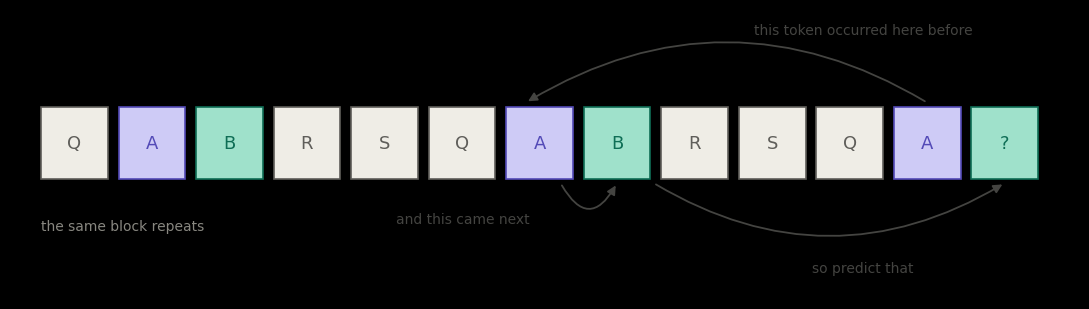

→ out\05_induction_diagram.png


In [170]:
GREY, MAUVE, TEAL = "#EFEDE6", "#CECBF6", "#9FE1CB"
EDGE = {GREY: "#5F5E5A", MAUVE: "#534AB7", TEAL: "#0F6E56"}
TOKENS = list("QABRS" * 2 + "QA") + ["?"]
FILL = {"A": MAUVE, "B": TEAL, "?": TEAL}

fig, ax = plt.subplots(figsize=(11, 3.2))
for i, tok in enumerate(TOKENS):
    c = FILL.get(tok, GREY)
    ax.add_patch(plt.Rectangle((i, 0), .86, .8, facecolor=c, edgecolor=EDGE[c], lw=1.2))
    ax.text(i + .43, .4, tok, ha="center", va="center", fontsize=13, color=EDGE[c])

# the three steps of the algorithm, drawn where they happen
arc = dict(arrowstyle="-|>", color="#444441", lw=1.3, mutation_scale=13)
ax.annotate("", xy=(6.25, .85), xytext=(11.43, .85),
            arrowprops=dict(connectionstyle="arc3,rad=.30", **arc))
ax.text(10.6, 1.62, "this token occurred here before", ha="center", fontsize=10, color="#444441")
ax.annotate("", xy=(7.43, -.05), xytext=(6.7, -.05),
            arrowprops=dict(connectionstyle="arc3,rad=.9", **arc))
ax.text(6.3, -.5, "and this came next", ha="right", fontsize=10, color="#444441")
ax.annotate("", xy=(12.43, -.05), xytext=(7.9, -.05),
            arrowprops=dict(connectionstyle="arc3,rad=.30", **arc))
ax.text(10.6, -1.05, "so predict that", ha="center", fontsize=10, color="#444441")

ax.text(0, -.45, "the same block repeats", fontsize=10, color="#888780", va="top")

ax.set_xlim(-.4, 13.4); ax.set_ylim(-1.35, 1.9); ax.axis("off")
fig.tight_layout(); fig.savefig(OUT / "05_induction_diagram.png", dpi=140)
plt.show()
print(f"→ {OUT / '05_induction_diagram.png'}")

In [171]:
def make_batch(bs: int, period: int | None = None):
    """A sequence tiled with period p. Returns (x, p)."""
    p = (torch.full((bs, 1), period) if period
         else torch.randint(P_LO, P_HI, (bs, 1)))
    base = torch.randint(0, V, (bs, T))
    idx = torch.arange(T)[None, :] % p          # 0,1,...,p-1,0,1,...
    return base.gather(1, idx), p


_x, _p = make_batch(1, period=5)
print(f"Example (period {_p.item()}):")
print("  ", _x[0, :20].tolist(), "...")
print("Position t is predictable only if t ≥ p: that token has occurred before.\n")

Example (period 5):
   [44, 47, 117, 64, 67, 44, 47, 117, 64, 67, 44, 47, 117, 64, 67, 44, 47, 117, 64, 67] ...
Position t is predictable only if t ≥ p: that token has occurred before.



## The model: an attention-only transformer

**Deliberately without an MLP.** That way the mechanism is visible in pure form: everything
the model can do is move information between positions. This is exactly the setting in which
induction heads were first described.

In [172]:
class AttnOnlyBlock(nn.Module):
    def __init__(self, d=D, heads=HEADS):
        super().__init__()
        self.h, self.dh = heads, d // heads
        self.qkv = nn.Linear(d, 3 * d, bias=False)
        self.proj = nn.Linear(d, d, bias=False)
        self.ln = nn.LayerNorm(d)
        self.last_attn: torch.Tensor | None = None

    def forward(self, x, keep_attn=False):
        B, t, C = x.shape
        q, k, v = self.qkv(self.ln(x)).view(B, t, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        att = (q @ k.transpose(-2, -1)) * self.dh ** -0.5
        causal = torch.tril(torch.ones(t, t, dtype=torch.bool, device=x.device))
        att = att.masked_fill(~causal, float("-inf")).softmax(-1)
        if keep_attn:
            self.last_attn = att.detach()
        y = (att @ v).transpose(1, 2).reshape(B, t, C)
        return x + self.proj(y)          # residual: the layer WRITES into the highway, does not replace it


class AttnOnlyLM(nn.Module):
    def __init__(self, n_layers=2, d=D, heads=HEADS):
        super().__init__()
        self.tok = nn.Embedding(V, d)
        self.pos = nn.Embedding(T, d)
        self.blocks = nn.ModuleList([AttnOnlyBlock(d, heads) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, V, bias=False)

    def forward(self, idx, keep_attn=False):
        x = self.tok(idx) + self.pos(torch.arange(idx.size(1), device=idx.device))
        for b in self.blocks:
            x = b(x, keep_attn)
        return self.head(self.ln_f(x))

## Two metrics

**loss at predictable positions** — computed only where the token has already occurred (`t ≥ p`).

**induction score** — for query `i` the correct key is `i − p + 1`:
the position right AFTER the previous occurrence of the same token.
We measure how much weight the head puts exactly there. Chance level ≈ 1/i.

In [173]:
@torch.no_grad()
def repeat_loss(model: AttnOnlyLM, bs=128, period=None) -> float:
    x, p = make_batch(bs, period)
    logits = model(x)
    ls = F.cross_entropy(logits[:, :-1].reshape(-1, V), x[:, 1:].reshape(-1),
                         reduction="none").view(bs, T - 1)
    tgt = torch.arange(1, T)[None, :]                 # index of the predicted token
    m = tgt >= p                                       # is it predictable at all
    return (ls * m).sum().item() / m.sum().item()


@torch.no_grad()
def induction_scores(model: AttnOnlyLM, bs=128) -> torch.Tensor:
    """(n_layers, n_heads) — mean weight on the "induction key" i − p + 1."""
    x, p = make_batch(bs)
    model(x, keep_attn=True)
    qi = torch.arange(T)[None, :]                      # (1, T)
    kj = (qi - p + 1).clamp(min=0)                     # (B, T)
    valid = (qi >= p).float()
    out = []
    for blk in model.blocks:
        a = blk.last_attn                              # (B, H, T, T)
        B, H = a.shape[:2]
        got = a.gather(-1, kj[:, None, :, None].expand(B, H, T, 1)).squeeze(-1)   # (B,H,T)
        out.append((got * valid[:, None, :]).sum((0, 2)) / valid.sum())
    return torch.stack(out)


@torch.no_grad()
def prev_token_scores(model: AttnOnlyLM, bs=128) -> torch.Tensor:
    """(n_layers, n_heads) — mean weight on the key one position back.

    Same protocol as induction_scores, so the two numbers in the panel titles below are
    comparable. Chance level is the same ~1/i."""
    x, _ = make_batch(bs)
    model(x, keep_attn=True)
    return torch.stack([blk.last_attn.diagonal(dim1=-2, dim2=-1, offset=-1).mean((0, 2))
                        for blk in model.blocks])


@torch.no_grad()
def context_set_loss(bs=256) -> float:
    """Loss of a strategy that knows WHICH tokens the sequence is made of, but not their order.

    Why this number is needed. Inside one sequence only p distinct tokens occur, p in [10,31),
    out of a vocabulary of 128. So there is a way to beat chance that needs no induction at
    all: at every step predict uniformly over the tokens seen so far. This is the ceiling of
    "I remember the contents of the context but not the order" — exactly the regime a
    one-layer attention-only model is confined to."""
    x, per = make_batch(bs)
    seen = torch.zeros(bs, T, V, dtype=torch.long)
    seen.scatter_(2, x.unsqueeze(-1), 1)
    n_seen = seen.cummax(dim=1).values.sum(-1)          # (B,T): distinct tokens up to t
    tgt = torch.arange(1, T)[None, :]                   # index of the predicted token
    m = (tgt >= per).float()
    # the next token has occurred before, so it is always inside the set: loss = ln |set|
    return (n_seen[:, :-1].float().log() * m).sum().item() / m.sum().item()


@torch.no_grad()
def loss_by_position(model: AttnOnlyLM, period=16, bs=256) -> torch.Tensor:
    x, _ = make_batch(bs, period)
    logits = model(x)
    ls = F.cross_entropy(logits[:, :-1].reshape(-1, V), x[:, 1:].reshape(-1), reduction="none")
    return ls.view(bs, T - 1).mean(0)

## Training: 1 layer vs 2 layers

In [174]:
def train(n_layers: int, seed: int = 0, steps=1200, bs=64, lr=1e-3, log_every=50):
    torch.manual_seed(seed)
    model = AttnOnlyLM(n_layers=n_layers)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    hist = {"step": [], "rep": [], "ind": []}
    t0 = time.time()
    for step in range(steps + 1):
        x, _ = make_batch(bs)
        logits = model(x)
        loss = F.cross_entropy(logits[:, :-1].reshape(-1, V), x[:, 1:].reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        if step % log_every == 0:
            hist["step"].append(step)
            hist["rep"].append(repeat_loss(model, bs=128))
            hist["ind"].append(induction_scores(model).max().item())
    print(f"  {n_layers}-layer seed {seed}: {time.time() - t0:.0f} s, "
          f"loss on repeats = {hist['rep'][-1]:.3f}, "
          f"max induction score = {hist['ind'][-1]:.3f}")
    return model, hist


SEEDS = (0, 1, 2)
CEILING = context_set_loss()
print(f"Chance-level loss (uniform over V={V}) = ln {V} = {math.log(V):.3f}")
print(f"Ceiling of 'I know the contents, not the order'  = {CEILING:.3f}")
print(f"Training {len(SEEDS)} seeds per depth.")

runs = {1: [train(1, seed=s) for s in SEEDS],
        2: [train(2, seed=s) for s in SEEDS]}
m1, h1 = runs[1][0]          # seed 0 — the models the pictures below are drawn from
m2, h2 = runs[2][0]


def spread(n_layers, key):
    v = [h[key][-1] for _, h in runs[n_layers]]
    return min(v), max(v)


def transition(hist):
    """First step at which the induction score is halfway to its final value."""
    half = hist["ind"][0] + (max(hist["ind"]) - hist["ind"][0]) * .5
    return next(st for st, v in zip(hist["step"], hist["ind"]) if v >= half)


print(f"""
Across {len(SEEDS)} seeds, final values (min-max):
  1 layer : loss {spread(1, 'rep')[0]:.3f}-{spread(1, 'rep')[1]:.3f},  \
induction score {spread(1, 'ind')[0]:.3f}-{spread(1, 'ind')[1]:.3f}
  2 layers: loss {spread(2, 'rep')[0]:.3f}-{spread(2, 'rep')[1]:.3f},  \
induction score {spread(2, 'ind')[0]:.3f}-{spread(2, 'ind')[1]:.3f}

The step at which the 2-layer transition happens, per seed: {', '.join(str(transition(h)) for _, h in runs[2])}.
The timing is reproducible; a single run could not have told us that.

The one-layer model covers {100 * (math.log(V) - spread(1, 'rep')[1]) / (math.log(V) - CEILING):.0f}% \
of the distance from chance ({math.log(V):.2f}) to the no-induction ceiling ({CEILING:.2f}),
and 0% of the distance to induction: its score is chance on every seed. Those are two
different axes, and only the second one is what Elhage's result is about.
""")

Chance-level loss (uniform over V=128) = ln 128 = 4.852
Ceiling of 'I know the contents, not the order'  = 2.834
Training 3 seeds per depth.
  1-layer seed 0: 30 s, loss on repeats = 3.845, max induction score = 0.030
  1-layer seed 1: 30 s, loss on repeats = 3.865, max induction score = 0.033
  1-layer seed 2: 24 s, loss on repeats = 3.817, max induction score = 0.033
  2-layer seed 0: 38 s, loss on repeats = 0.328, max induction score = 0.466
  2-layer seed 1: 38 s, loss on repeats = 0.282, max induction score = 0.430
  2-layer seed 2: 36 s, loss on repeats = 0.387, max induction score = 0.438

Across 3 seeds, final values (min-max):
  1 layer : loss 3.817-3.865,  induction score 0.030-0.033
  2 layers: loss 0.282-0.387,  induction score 0.430-0.466

The step at which the 2-layer transition happens, per seed: 650, 600, 600.
The timing is reproducible; a single run could not have told us that.

The one-layer model covers 49% of the distance from chance (4.85) to the no-induction ceili

## Result

**The two-layer model makes a phase transition**: the loss drops as a step, not smoothly,
and at that same moment the induction score rises. The mechanism does not "gradually
improve", it appears — and that is visible both in the loss and in the attention weights.
Which step it happens on varies with the seed; that it happens does not.

**The one-layer model does not build the mechanism** — its induction score stays at chance
on every seed. But read the left panel carefully: its loss does NOT stay at chance either.
It settles about a nat and a third below, and that has a specific explanation.

Inside one sequence there are only p distinct tokens, p in [10,31), out of 128. So there is
strategy that needs no induction at all: remember WHICH tokens the sequence is made of and
predict uniformly over them. The dotted line on the left panel is the ceiling of that
strategy; how far the one-layer model gets towards it is printed with the results.

So "one layer cannot" is precise only about the mechanism. One layer learns the CONTENTS of
the context; it cannot learn the ORDER, because to search by "what came before position j"
somebody must first have written that into position j. Elhage's skip-trigrams are exactly
this: "B occurred in the context, so B is likely" — with no link "after A comes B".

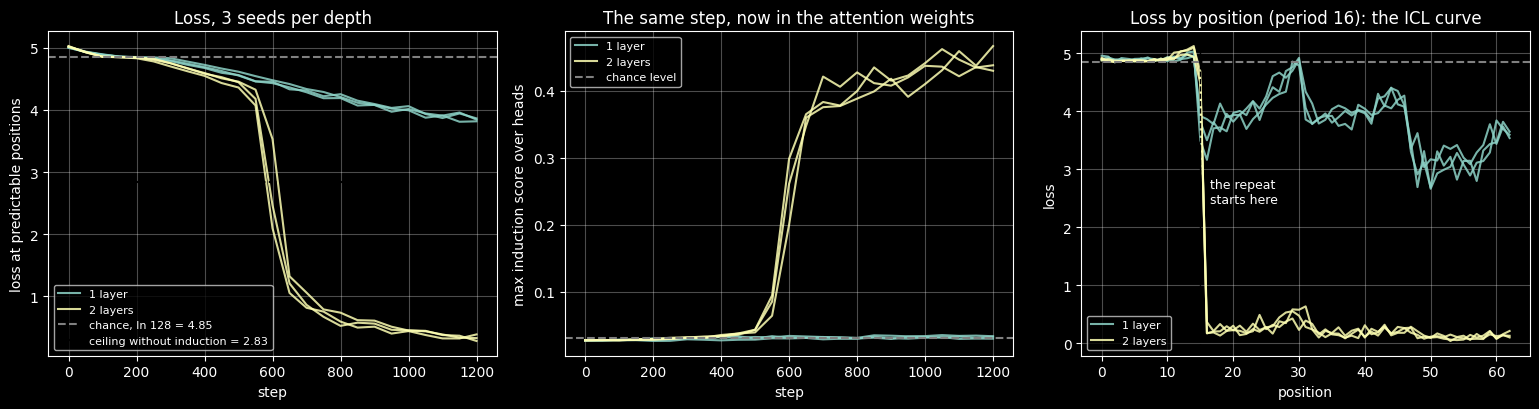

→ out\05_induction_training.png


In [175]:
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.2))
STYLE = {1: ("C0", "1 layer"), 2: ("C1", "2 layers")}      # one line per seed, one colour per depth

for n, (colour, lab) in STYLE.items():
    for k, (_, h) in enumerate(runs[n]):
        ax[0].plot(h["step"], h["rep"], color=colour, lw=1.5, alpha=.85,
                   label=lab if k == 0 else None)
ax[0].axhline(math.log(V), ls="--", c="gray", label=f"chance, ln {V} = {math.log(V):.2f}")
ax[0].axhline(CEILING, ls=":", c="k",
              label=f"ceiling without induction = {CEILING:.2f}")
ax[0].set_xlabel("step"); ax[0].set_ylabel("loss at predictable positions")
ax[0].set_title(f"Loss, {len(SEEDS)} seeds per depth")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

for n, (colour, lab) in STYLE.items():
    for k, (_, h) in enumerate(runs[n]):
        ax[1].plot(h["step"], h["ind"], color=colour, lw=1.5, alpha=.85,
                   label=lab if k == 0 else None)
ax[1].axhline(1 / (T / 2), ls="--", c="gray", label="chance level")
ax[1].set_xlabel("step"); ax[1].set_ylabel("max induction score over heads")
ax[1].set_title("The same step, now in the attention weights")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

PER = 16
for n, (colour, lab) in STYLE.items():
    for k, (m, _) in enumerate(runs[n]):
        ax[2].plot(loss_by_position(m, period=PER).numpy(), color=colour, lw=1.5, alpha=.85,
                   label=lab if k == 0 else None)
ax[2].axvline(PER - 1, ls="--", c="k", lw=1)
ax[2].text(PER + .5, math.log(V) * .5, "the repeat\nstarts here", fontsize=9)
ax[2].axhline(math.log(V), ls="--", c="gray")
ax[2].set_xlabel("position"); ax[2].set_ylabel("loss")
ax[2].set_title(f"Loss by position (period {PER}): the ICL curve")
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

fig.tight_layout(); fig.savefig(OUT / "05_induction_training.png", dpi=140)
plt.show()
print(f"→ {OUT / '05_induction_training.png'}")

## Who exactly does this: labelling the heads

Worth looking at every head rather than at the winner. "An induction head appeared" and
"the whole second layer became induction heads" are different statements, and only the
per-head table tells them apart.

In [176]:
for name, group in [("1 layer", runs[1]), ("2 layers", runs[2])]:
    print(f"\n{name} — induction score per head, chance level ≈ {2 / T:.3f}")
    for seed, (m, _) in zip(SEEDS, group):
        sc = induction_scores(m)
        for l in range(sc.shape[0]):
            row = "  ".join(f"H{h}={sc[l, h]:.3f}" for h in range(sc.shape[1]))
            print(f"  seed {seed}, layer {l}: {row}")

hi = [(seed, l, h)
      for seed, (m, _) in zip(SEEDS, runs[2])
      for l, row in enumerate(induction_scores(m))
      for h, v in enumerate(row) if v > 0.2]
print(f"""
Heads with an induction score above 0.2, over all {len(SEEDS)} seeds: {len(hi)}, out of
{len(SEEDS) * HEADS} heads in layer 1. So this is not "one head found the algorithm" — the
whole search layer converges to it. Picking an argmax and calling it "the induction head"
would hide that.

Layer 0 is not the mirror image of it. Every one of its heads is BELOW chance on induction
(they are not searching), but only some of them are prev-token heads — look at the two
scores in the panel titles. Splitting four heads over one job is not required, and the model
does not do it.
""")


1 layer — induction score per head, chance level ≈ 0.031
  seed 0, layer 0: H0=0.031  H1=0.030  H2=0.030  H3=0.030
  seed 1, layer 0: H0=0.032  H1=0.032  H2=0.030  H3=0.035
  seed 2, layer 0: H0=0.029  H1=0.030  H2=0.029  H3=0.030

2 layers — induction score per head, chance level ≈ 0.031
  seed 0, layer 0: H0=0.019  H1=0.025  H2=0.026  H3=0.020
  seed 0, layer 1: H0=0.437  H1=0.436  H2=0.430  H3=0.440
  seed 1, layer 0: H0=0.024  H1=0.022  H2=0.028  H3=0.019
  seed 1, layer 1: H0=0.437  H1=0.463  H2=0.479  H3=0.395
  seed 2, layer 0: H0=0.018  H1=0.028  H2=0.028  H3=0.019
  seed 2, layer 1: H0=0.434  H1=0.452  H2=0.400  H3=0.403

Heads with an induction score above 0.2, over all 3 seeds: 12, out of
12 heads in layer 1. So this is not "one head found the algorithm" — the
whole search layer converges to it. Picking an argmax and calling it "the induction head"
would hide that.

Layer 0 is not the mirror image of it. Every one of its heads is BELOW chance on induction
(they are not sear

## The algorithm the model ended up with

```
input:   ... A B ... ... A ?

layer 0 — prev-token head
    into position B we write "A was before me"
    → B acquires the fingerprint [A]

layer 1 — induction head
    the query at the last A looks for the key [A]
    → finds position B
    → copies B into the prediction

answer:  B
```

Two layers are needed because one writes the fingerprint and the other searches by it —
K-composition through the residual highway.

## Looking at the attention matrices

Every head of both layers, from the seed-0 model. Note the two protocols: the PICTURES are
one sequence with period 16, the SCORES in the titles are averages over 128 sequences with
a random period. A head can look striking on one example and be unremarkable on average —
that is exactly why both are here.

Three things are easier to see here than in the table.

Row 1 is uniformly induction: the layer converged as a whole, not one lucky head. Row 0 is
not uniform at all — some of its heads carry the prev-token stripe and some do not.

The dotted lines mark **three** keys, not one. With T=64 and period 16 the block repeats
four times, so the token following "the previous A" exists at offsets 15, 31 and 47. The
heads use all three and prefer the oldest — consistent with row 0, whose stripe is
brightest at small i, where the fingerprints are cleanest.

And before the repeat begins (i < 16) there is nothing to copy, so row 1 parks its
attention on position 0: the bright column on the left. That is the attention sink from
`04` — a head with nothing to do still has to put its softmax mass somewhere.

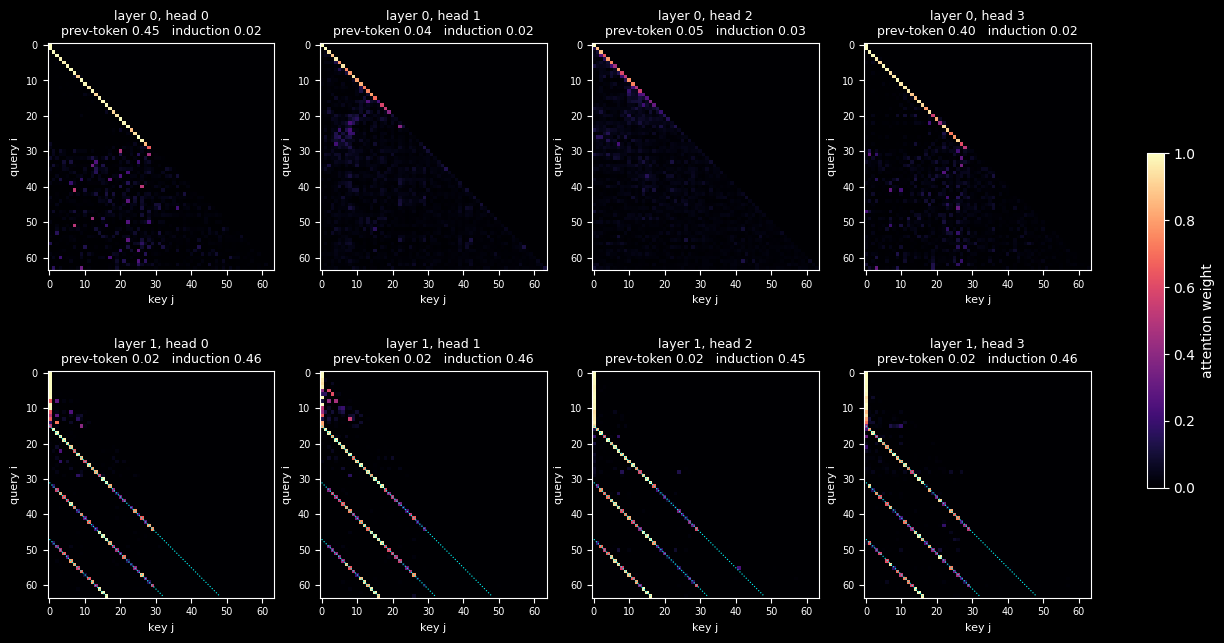

→ out\05_induction_heads.png


In [177]:
with torch.no_grad():
    x, _ = make_batch(1, period=PER)
    m2(x, keep_attn=True)
    A = [blk.last_attn[0] for blk in m2.blocks]        # a list of (H, T, T)

sc, pv = induction_scores(m2), prev_token_scores(m2)
fig, axes = plt.subplots(len(A), HEADS, figsize=(3.6 * HEADS, 3.9 * len(A)))
for l in range(len(A)):
    for h in range(HEADS):
        axi = axes[l, h]
        im = axi.imshow(A[l][h].numpy(), cmap="magma", vmin=0, vmax=1)
        axi.set_title(f"layer {l}, head {h}\nprev-token {pv[l, h]:.2f}   "
                      f"induction {sc[l, h]:.2f}", fontsize=9)
        axi.set_xlabel("key j", fontsize=8); axi.set_ylabel("query i", fontsize=8)
        axi.tick_params(labelsize=7)
        if l:                                          # the search layer: mark every repeat
            for off in range(PER - 1, T - 1, PER):
                axi.plot([0, T - 1 - off], [off, T - 1], ls=":", c="cyan", lw=.8)
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=.015, label="attention weight")
fig.savefig(OUT / "05_induction_heads.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"→ {OUT / '05_induction_heads.png'}")

## Takeaways: induction heads

* **Why many heads.** A head is one relation. Prev-token and induction are two different
  relations and do not fit into a single softmax row.
* **Why depth.** The mechanism is assembled out of layers, through composition over the
  residual highway: layer 1 reads what layer 0 wrote.
* **What in-context learning is here.** Not magic — a concrete copying scheme that can be
  located, measured and broken.
* **How to check a demo for shortcuts.** With a fixed period a positional head solves the
  task, and the whole experiment would have looked convincing and been wrong.

## Optional: the same thing in a real GPT-2

Needs `transformers` + a model download (~550 MB). The known induction heads
in GPT-2 small are around L5H1 and L5H5. The code is the same: feed a repeating random
sequence and compute the weight on key `i − p + 1` across all heads.

Interactive tools for showing attention on a real model:
* [CircuitsVis](https://github.com/TransformerLensOrg/CircuitsVis) — `attention_patterns(...)`
  renders straight into the notebook, and has an "all heads of a layer at once" mode;
* [BertViz](https://github.com/jessevig/bertviz) — head view / model view;
* [TransformerLens](https://github.com/TransformerLensOrg/TransformerLens) — if you want
  not only to look but also to patch activations.

---

# 06 — RoPE: position as a rotation

**Lecture 1, block 2.**

**In modern LLMs position is an operation performed during attention, not a term added
to the embedding.** Two pictures are enough to see how that works:

1. what the rotation does to one vector — every 2-D subspace spins at its own rate;
2. what it buys — the attention score ends up depending only on the DISTANCE `m − n`.

Dependencies: `torch`, `matplotlib`, `plotly` (the 3-D helix).

Primary sources: RoPE — [arXiv:2104.09864](https://arxiv.org/abs/2104.09864);
an illustrated walkthrough — [EleutherAI blog](https://blog.eleuther.ai/rotary-embeddings/).

In [178]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)
torch.manual_seed(0)

## 1. RoPE

A vector of length `d` is split into `d/2` two-dimensional subspaces.
Subspace `i` is rotated by the angle `m·θ_i`, where `m` is the position
and `θ_i = base^(-2i/d)` is that coordinate pair's own frequency.

In [179]:
def rope_freqs(d: int, base: float = 10000.0) -> torch.Tensor:
    """θ_i for i = 0..d/2-1. A geometric progression from 1 down to 1/base."""
    return base ** (-torch.arange(0, d, 2).float() / d)


def apply_rope(x: torch.Tensor, pos: torch.Tensor, base: float = 10000.0) -> torch.Tensor:
    """x: (..., T, d) → rotated x. Coordinate pairs (0,1), (2,3), ... — as in the paper."""
    d = x.shape[-1]
    ang = pos[:, None].float() * rope_freqs(d, base)[None, :]     # (T, d/2)
    cos, sin = ang.cos(), ang.sin()
    x1, x2 = x[..., 0::2], x[..., 1::2]                            # even / odd
    return torch.stack([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1).flatten(-2)


d = 64
q = torch.randn(1, d)
print("norm before the rotation:", q.norm().item())
print("norm after:              ", apply_rope(q, torch.tensor([137])).norm().item())
print("→ RoPE is an orthogonal transform: it does not change the length, only the direction.\n")

print("""A note about implementations: in HF/Llama the pairs are not the adjacent (0,1),(2,3)...
but the "halves" (0, d/2), (1, d/2+1), ... — that vectorizes more conveniently (rotate_half).
It is a PERMUTATION of coordinates, mathematically equivalent. But weights do not transfer
directly between the two conventions — a classic source of bugs when porting.
""")

norm before the rotation: 8.370453834533691
norm after:               8.370452880859375
→ RoPE is an orthogonal transform: it does not change the length, only the direction.

A note about implementations: in HF/Llama the pairs are not the adjacent (0,1),(2,3)...
but the "halves" (0, d/2), (1, d/2+1), ... — that vectorizes more conveniently (rotate_half).
It is a PERMUTATION of coordinates, mathematically equivalent. But weights do not transfer
directly between the two conventions — a classic source of bugs when porting.



## 2. One vector, many clocks

The same query at positions `m = 0…32`, one dial per 2-D subspace. The dot is where the
subspace points; its colour is the position. Subspace 0 turns five times over 32 tokens and
starts landing on places it has already been — at that speed two distant positions become
indistinguishable. Subspace 20 has barely moved. That spread is what the base θ buys: the
fast pairs resolve neighbours, the slow ones carry long range.

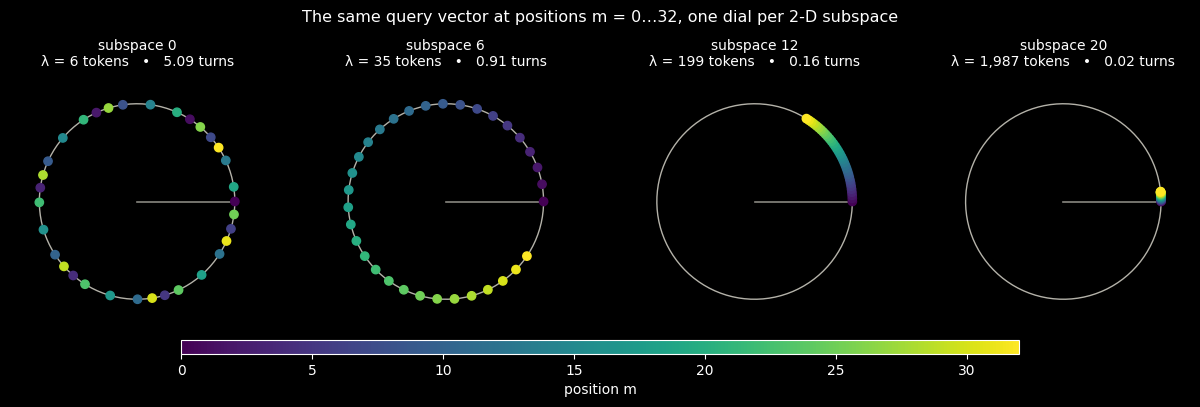

→ out\06_rope_dials.png


In [180]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

SUBS, MMAX = [0, 6, 12, 20], 32
th = rope_freqs(d)
fig, ax = plt.subplots(1, len(SUBS), figsize=(12.5, 3.9))
circle = np.linspace(0, 2 * np.pi, 200)
for a, i in zip(ax, SUBS):
    a.plot(np.cos(circle), np.sin(circle), color="#B4B2A9", lw=1)
    a.plot([0, 1], [0, 0], color="#888780", lw=1.2, zorder=2)
    m = np.arange(MMAX + 1)
    ang = m * th[i].item()
    a.scatter(np.cos(ang), np.sin(ang), c=m, cmap="viridis", s=36, zorder=3)
    lam = 2 * math.pi / th[i].item()
    a.set_title(f"subspace {i}\nλ = {lam:,.0f} tokens   \u2022   {MMAX / lam:.2f} turns",
                fontsize=10)
    a.set_aspect("equal"); a.set_xlim(-1.3, 1.3); a.set_ylim(-1.3, 1.3); a.axis("off")
fig.suptitle(f"The same query vector at positions m = 0…{MMAX}, one dial per 2-D subspace",
             fontsize=11.5)
fig.tight_layout(rect=[0, .06, 1, .93])
cb = fig.colorbar(ScalarMappable(norm=Normalize(0, MMAX), cmap="viridis"),
                  ax=ax, orientation="horizontal", fraction=.05, pad=.04, aspect=60)
cb.set_label("position m", fontsize=10)
fig.savefig(OUT / "06_rope_dials.png", dpi=140)
plt.show()
print(f"→ {OUT / '06_rope_dials.png'}")

## 3. The same thing as a helix

A toy setup so all the speeds fit on one screen: `d = 10`, so five subspaces, and base 100
instead of 10 000. Position runs up and each subspace winds around it — the fastest makes
6.4 turns over 40 tokens, the slowest 0.16.

The five helices are drawn at different radii **only so they can be told apart**. In RoPE
every subspace lives on the same unit circle; the radius here carries no meaning. Dots mark
the integer positions — on the innermost helix, consecutive tokens are already almost half a
turn apart, which is what "the fast subspaces alias" looks like.

In [181]:
import plotly.graph_objects as go

D_TOY, BASE_TOY, M_MAX = 10, 100.0, 40
th_toy = rope_freqs(D_TOY, BASE_TOY).numpy()
m_line = np.linspace(0, M_MAX, 600)
m_dots = np.arange(0, M_MAX + 1)

fig3d = go.Figure()
for i, t in enumerate(th_toy):
    r = 1 + .5 * i
    lam, turns = 2 * math.pi / t, M_MAX * t / (2 * math.pi)
    name = f"i={i}   θ={t:.3f}   λ={lam:,.0f}   {turns:.2f} turns"
    fig3d.add_trace(go.Scatter3d(
        x=r * np.cos(m_line * t), y=r * np.sin(m_line * t), z=m_line,
        mode="lines", line=dict(width=5), name=name, legendgroup=name))
    fig3d.add_trace(go.Scatter3d(
        x=r * np.cos(m_dots * t), y=r * np.sin(m_dots * t), z=m_dots,
        mode="markers", marker=dict(size=2.5), name=name, legendgroup=name,
        showlegend=False))
fig3d.update_layout(
    title=(f"base {BASE_TOY:.0f},  d={D_TOY} → {len(th_toy)} subspaces,  positions 0…{M_MAX}"
           f"<br><sub>θ<sub>i</sub> = {BASE_TOY:.0f}<sup>−2i/{D_TOY}</sup> — the base is what sets the whole ladder</sub>"),
    scene=dict(xaxis_title="cos(mθ)", yaxis_title="sin(mθ)", zaxis_title="position m",
               aspectmode="manual", aspectratio=dict(x=1, y=1, z=1.9),
               camera=dict(eye=dict(x=1.85, y=-1.85, z=0.6))),
    height=720, margin=dict(l=0, r=0, t=44, b=0),
)
fig3d.write_html(OUT / "06_rope_helix.html", include_plotlyjs="cdn")
_show_html(OUT / "06_rope_helix.html", height=720)
print(f"→ {OUT / '06_rope_helix.html'}")

→ out\06_rope_helix.html


## 4. Where relative position comes from

Fix one query and one key and never change them. Rotate both by their positions and take the
dot product for every pair `(m, n)`. Nothing in the picture below varies except the two
positions — so any structure in it is the doing of the rotation alone.

One cosmetic step: `k` is made orthogonal to `q` first. Their dot product would otherwise
add the same constant to every cell and push the whole map to one side of the colour scale.
It shifts nothing about the pattern, only centres it.

spread WITHIN a diagonal (same m-n):   1.7e-06
spread BETWEEN diagonals:              0.331


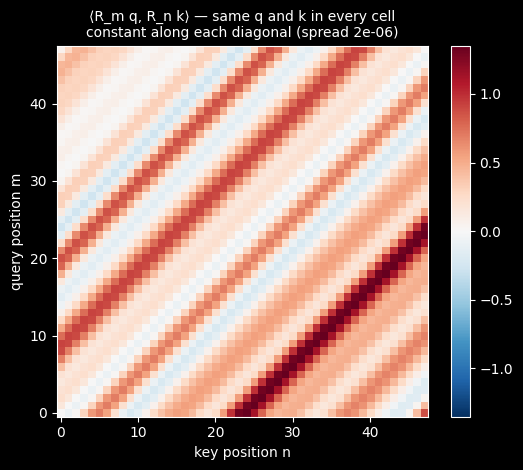

→ out\06_rope_relative.png

The stripes are the whole point. A cell's value is fixed by m - n and by nothing else: two
tokens twenty apart score the same whether they sit at positions 0 and 20 or at 300 and 320.

Nobody put that in. It falls out of the algebra of rotations — rotating both vectors by their
own angles and taking a dot product leaves only the difference of the angles:

    <R_m q, R_n k> = <R_(m-n) q, k>

which is what the 2e-06 above measures. Relative position is not a feature bolted on
top of RoPE; it IS RoPE.



In [182]:
T = 48
pos = torch.arange(T)
qq, kk = torch.randn(d), torch.randn(d)
kk -= (kk @ qq) / (qq @ qq) * qq          # drop the constant content term: what is left is position
Q = apply_rope(qq.expand(T, d).clone(), pos)
K = apply_rope(kk.expand(T, d).clone(), pos)
M = ((Q @ K.T) / math.sqrt(d)).numpy()

within = max((np.diagonal(M, o).max() - np.diagonal(M, o).min())
             for o in range(-T + 1, T) if len(np.diagonal(M, o)) > 1)
between = np.std([np.diagonal(M, o).mean() for o in range(-T + 1, T)])
print(f"spread WITHIN a diagonal (same m-n):   {within:.1e}")
print(f"spread BETWEEN diagonals:              {between:.3f}")

fig, ax = plt.subplots(figsize=(5.6, 4.8))
v = np.abs(M).max()
im = ax.imshow(M, cmap="RdBu_r", vmin=-v, vmax=v, origin="lower")
ax.set_xlabel("key position n"); ax.set_ylabel("query position m")
ax.set_title(f"\u27e8R_m q, R_n k\u27e9 \u2014 same q and k in every cell\n"
             f"constant along each diagonal (spread {within:.0e})", fontsize=10)
fig.colorbar(im, ax=ax, fraction=.046)
fig.tight_layout(); fig.savefig(OUT / "06_rope_relative.png", dpi=140)
plt.show()
print(f"→ {OUT / '06_rope_relative.png'}")

print(f"""
The stripes are the whole point. A cell's value is fixed by m - n and by nothing else: two
tokens twenty apart score the same whether they sit at positions 0 and 20 or at 300 and 320.

Nobody put that in. It falls out of the algebra of rotations — rotating both vectors by their
own angles and taking a dot product leaves only the difference of the angles:

    <R_m q, R_n k> = <R_(m-n) q, k>

which is what the {within:.0e} above measures. Relative position is not a feature bolted on
top of RoPE; it IS RoPE.
""")

## Takeaways: RoPE
* Position is applied inside attention, to `q` and `k` — not added to the embedding.
* The rotation is orthogonal: the length of the vector is untouched, only its phase moves.
* Each 2-D subspace has its own rate. Fast ones tell neighbours apart, slow ones reach far,
  and that division is what the base θ controls.
* The attention score depends only on `m - n`. That is an identity, not an approximation —
  measured above at 1e-06.

**Not covered here:** ALiBi, NoPE, per-layer embeddings, and what happens beyond the
training length — where the fast subspaces have already wrapped around.

---

# 07 — The KV cache: the second cost axis

**Lecture 1, block 3.** This is where the duality "training in parallel /
inference sequentially" closes, the reason the KV cache exists at all.

We do four things:
1. write generation with and without a cache, **verify that the logits match** (otherwise the
   cache is broken);
2. measure the time per token: without a cache it grows linearly, with a cache it is almost constant;
3. compute the cache size from the formula and compare it with the size of the weights themselves
   for real models (the main "wow" moment);
4. work through prefill vs decode — why these are two different problems for the hardware.

Dependencies: `torch`, `matplotlib`.

In [183]:
from __future__ import annotations

import json
import sys
import time
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)
torch.manual_seed(0)

## 1. A model with a cache — the minimal implementation

The cache is simply "do not recompute K and V for tokens that have not changed".
The only thing that changes in the code: `k, v` are concatenated with the past,
and `q` is computed for the new token only.

In [184]:
@dataclass
class Cfg:
    vocab: int = 512
    d: int = 256
    n_layers: int = 6
    n_heads: int = 8
    n_kv_heads: int = 8      # = n_heads → MHA; 1 → MQA; in between → GQA
    max_len: int = 2048


class Attn(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.c = c
        self.dh = c.d // c.n_heads
        self.q = nn.Linear(c.d, c.n_heads * self.dh, bias=False)
        self.k = nn.Linear(c.d, c.n_kv_heads * self.dh, bias=False)
        self.v = nn.Linear(c.d, c.n_kv_heads * self.dh, bias=False)
        self.o = nn.Linear(c.n_heads * self.dh, c.d, bias=False)

    def forward(self, x, cache: dict | None = None):
        B, T, _ = x.shape
        c = self.c
        q = self.q(x).view(B, T, c.n_heads, self.dh).transpose(1, 2)
        k = self.k(x).view(B, T, c.n_kv_heads, self.dh).transpose(1, 2)
        v = self.v(x).view(B, T, c.n_kv_heads, self.dh).transpose(1, 2)

        if cache is not None:                      # ← the whole point of the KV cache
            if "k" in cache:
                k = torch.cat([cache["k"], k], dim=2)
                v = torch.cat([cache["v"], v], dim=2)
            cache["k"], cache["v"] = k, v

        if c.n_kv_heads != c.n_heads:              # GQA: replicate the KV heads across groups
            rep = c.n_heads // c.n_kv_heads
            k = k.repeat_interleave(rep, dim=1)
            v = v.repeat_interleave(rep, dim=1)

        # is_causal only works when q and k have the same length (prefill).
        # On a decode step a q of length 1 sees the whole past — no mask is needed at all.
        y = F.scaled_dot_product_attention(q, k, v, is_causal=(k.size(2) == T and T > 1))
        return self.o(y.transpose(1, 2).reshape(B, T, -1))


class Block(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(c.d), nn.LayerNorm(c.d)
        self.attn = Attn(c)
        self.mlp = nn.Sequential(nn.Linear(c.d, 4 * c.d), nn.GELU(), nn.Linear(4 * c.d, c.d))

    def forward(self, x, cache=None):
        x = x + self.attn(self.n1(x), cache)
        return x + self.mlp(self.n2(x))


class GPT(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__()
        self.c = c
        self.tok = nn.Embedding(c.vocab, c.d)
        self.pos = nn.Embedding(c.max_len, c.d)
        self.blocks = nn.ModuleList([Block(c) for _ in range(c.n_layers)])
        self.nf = nn.LayerNorm(c.d)
        self.head = nn.Linear(c.d, c.vocab, bias=False)

    def forward(self, idx, caches: list | None = None, pos_offset: int = 0):
        T = idx.size(1)
        p = torch.arange(pos_offset, pos_offset + T, device=idx.device)   # continue, do not restart at 0
        x = self.tok(idx) + self.pos(p)
        for i, b in enumerate(self.blocks):
            x = b(x, None if caches is None else caches[i])
        return self.head(self.nf(x))


cfg = Cfg()
model = GPT(cfg).eval()
print(f"model: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M parameters")

model: 5.5M parameters


## 2. Correctness check — a mandatory step

A cache is easy to break (position offset, mask, concatenation order), and the model will
happily keep generating "something that looks like text". The only reliable check is to
**compare the logits numerically** against the implementation without a cache.

In [185]:
@torch.no_grad()
def generate_nocache(m: GPT, prompt: torch.Tensor, n_new: int):
    """Every step is a full forward over the whole sequence. O(n²) in total."""
    idx = prompt.clone()
    logits_trace = []
    for _ in range(n_new):
        logits = m(idx)[:, -1]
        logits_trace.append(logits)
        idx = torch.cat([idx, logits.argmax(-1, keepdim=True)], dim=1)
    return idx, torch.stack(logits_trace)


@torch.no_grad()
def generate_cached(m: GPT, prompt: torch.Tensor, n_new: int):
    """Prefill the whole prompt, then one token at a time. O(n) per token."""
    caches = [dict() for _ in m.blocks]
    logits = m(prompt, caches, pos_offset=0)[:, -1]
    idx = prompt.clone()
    logits_trace = []
    for step in range(n_new):
        logits_trace.append(logits)
        nxt = logits.argmax(-1, keepdim=True)
        idx = torch.cat([idx, nxt], dim=1)
        logits = m(nxt, caches, pos_offset=idx.size(1) - 1)[:, -1]
    return idx, torch.stack(logits_trace)


prompt = torch.randint(0, cfg.vocab, (1, 16))
a, la = generate_nocache(model, prompt, 24)
b, lb = generate_cached(model, prompt, 24)
print(f"do the tokens match: {torch.equal(a, b)}")
print(f"max |Δ logits|:      {(la - lb).abs().max():.2e}   ← should be ~1e-5, no more")
assert torch.equal(a, b), "the cache is broken!"
print("""
Typical bugs caught by exactly this check:
  • forgot pos_offset → the positional embeddings restart at every step;
  • left is_causal=True on the decode step → the token only sees itself;
  • mixed up the order of cat(prev, new) → the "future" ended up on the left.
""")

do the tokens match: True
max |Δ logits|:      1.43e-06   ← should be ~1e-5, no more

Typical bugs caught by exactly this check:
  • forgot pos_offset → the positional embeddings restart at every step;
  • left is_causal=True on the decode step → the token only sees itself;
  • mixed up the order of cat(prev, new) → the "future" ended up on the left.



## 3. Measurement: how much time the cache saves

without cache: 3637 ms for 256 tokens (first 4.1 ms → last 24.6 ms)
with cache:    841 ms (first 3.7 ms → last 3.6 ms)
total speedup: x4.3

The model here is tiny and Python overhead eats a lot of the time, so the gain is modest.
What to take away is the SHAPE of the curve, not the factor: without a cache the step time
grows linearly with the number of tokens generated so far, with a cache it stays constant.
Which also means the factor is not a constant but a function of the context length, so
"the cache is N times faster" is a question with no answer apart from a length.
On a real model with a context of thousands of tokens this is the difference between
"it works" and "it does not work at all".



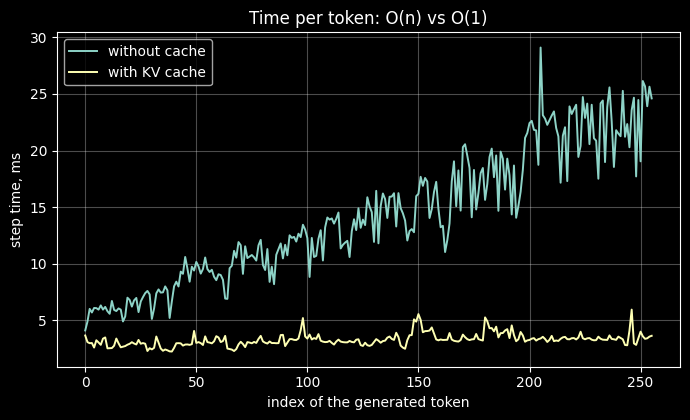

→ out\07_kv_time.png


In [186]:
@torch.no_grad()
def timed_generate(m, prompt, n_new, cached: bool):
    ts = []
    if cached:
        caches = [dict() for _ in m.blocks]
        logits = m(prompt, caches, pos_offset=0)[:, -1]
        idx = prompt.clone()
        for _ in range(n_new):
            t0 = time.perf_counter()
            nxt = logits.argmax(-1, keepdim=True)
            idx = torch.cat([idx, nxt], 1)
            logits = m(nxt, caches, pos_offset=idx.size(1) - 1)[:, -1]
            ts.append((time.perf_counter() - t0) * 1e3)
    else:
        idx = prompt.clone()
        for _ in range(n_new):
            t0 = time.perf_counter()
            logits = m(idx)[:, -1]
            idx = torch.cat([idx, logits.argmax(-1, keepdim=True)], 1)
            ts.append((time.perf_counter() - t0) * 1e3)
    return ts


N_NEW, ROUNDS = 256, 3
prompt = torch.randint(0, cfg.vocab, (1, 32))


def best_of(cached: bool):
    """Per-token minimum over several generations. Anything else running on the machine can
    only ADD time, so the minimum is the honest per-token cost; a single pass is mostly noise."""
    runs = [timed_generate(model, prompt, N_NEW, cached=cached) for _ in range(ROUNDS)]
    return [min(col) for col in zip(*runs)]


t_no, t_yes = best_of(cached=False), best_of(cached=True)
print(f"without cache: {sum(t_no):.0f} ms for {N_NEW} tokens "
      f"(first {t_no[0]:.1f} ms → last {t_no[-1]:.1f} ms)")
print(f"with cache:    {sum(t_yes):.0f} ms "
      f"(first {t_yes[0]:.1f} ms → last {t_yes[-1]:.1f} ms)")
print(f"total speedup: x{sum(t_no) / sum(t_yes):.1f}")
print("""
The model here is tiny and Python overhead eats a lot of the time, so the gain is modest.
What to take away is the SHAPE of the curve, not the factor: without a cache the step time
grows linearly with the number of tokens generated so far, with a cache it stays constant.
Which also means the factor is not a constant but a function of the context length, so
"the cache is N times faster" is a question with no answer apart from a length.
On a real model with a context of thousands of tokens this is the difference between
"it works" and "it does not work at all".
""")

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(t_no, label="without cache", lw=1.4)
ax.plot(t_yes, label="with KV cache", lw=1.4)
ax.set_xlabel("index of the generated token"); ax.set_ylabel("step time, ms")
ax.set_title("Time per token: O(n) vs O(1)")
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "07_kv_time.png", dpi=140)
plt.show()
print(f"→ {OUT / '07_kv_time.png'}")

## 4. Cache size: the formula and real models

```
bytes = 2 · n_layers · n_kv_heads · d_head · seq_len · batch · sizeof(dtype)
         ↑ K and V
```
It grows **linearly** in length and in batch. The model weights meanwhile are a constant.
Hence the main fact about inference: at long context or large batch,
memory is eaten not by the model but by the cache.

In [187]:
@dataclass
class ModelSpec:
    name: str
    layers: int
    d: int
    n_heads: int
    n_kv: int              # number of KV heads
    d_head: int
    params_b: float        # total parameters, billions
    active_b: float        # active parameters per token, billions (for MoE)
    swa: int = 0           # sliding-window size, 0 = full attention
    swa_ratio: str = ""    # e.g. "5:1" — five local layers per one global
    note: str = ""

    def kv_bytes_per_token(self, dtype_bytes=2) -> float:
        return 2 * self.layers * self.n_kv * self.d_head * dtype_bytes

    def mha_equivalent(self, dtype_bytes=2) -> float:
        """What it would be if the same model used classic MHA."""
        return 2 * self.layers * self.n_heads * self.d_head * dtype_bytes


# ⚠ The values are a snapshot of the model cards, so check them against config.json
# (see the --fetch flag below) before relying on them: configs do get edited.
MODELS = [
    ModelSpec("GPT-2 small",      12,   768, 12, 12,  64, 0.124, 0.124, note="MHA, 2019"),
    ModelSpec("Llama-2-7B",       32,  4096, 32, 32, 128, 6.7,   6.7,   note="MHA"),
    ModelSpec("Llama-3-8B",       32,  4096, 32,  8, 128, 8.0,   8.0,   note="GQA g=4"),
    ModelSpec("Llama-3-70B",      80,  8192, 64,  8, 128, 70.6,  70.6,  note="GQA g=8"),
    ModelSpec("Qwen3-32B",        64,  5120, 64,  8, 128, 32.8,  32.8,  note="GQA g=8"),
    ModelSpec("Gemma-3-27B",      62,  5376, 32, 16, 128, 27.4,  27.4,
              swa=1024, swa_ratio="5:1", note="SWA 5:1 — number below ignores the window"),
    ModelSpec("gpt-oss-120B",     36,  2880, 64,  8,  64, 116.8, 5.1,
              swa=128, swa_ratio="1:1", note="MoE + SWA on every other layer"),
]

print(f"{'model':<16}{'total':>8}{'active':>8}{'weights':>9}{'KB/tok':>9}"
      f"{'cache @128k':>12}{'cache/wts':>10}  note")
print("-" * 105)
rows = []
for m in MODELS:
    kv = m.kv_bytes_per_token()
    w_gb = m.params_b * 1e9 * 2 / 2 ** 30                 # bf16
    c_gb = kv * 131072 / 2 ** 30
    rows.append((m, kv, w_gb, c_gb))
    b = lambda v: f"{v:>7.1f}B" if v < 10 else f"{v:>7.0f}B"
    print(f"{m.name:<16}{b(m.params_b)}{b(m.active_b)}{w_gb:>8.1f}G"
          f"{kv / 1024:>9.1f}{c_gb:>11.1f}G{c_gb / w_gb:>10.2f}  {m.note}")

print("""
How to read this:
  • "KB/tok" is how many kilobytes of cache ONE token adds. This is the key constant of
    inference: multiply by the length and by the batch.
  • Llama-2-7B → Llama-3-8B: GQA cut the cache by exactly 4× (32 KV heads → 8).
  • Llama-3-70B: 80 layers against 32, but the same 8 KV heads — the cache grew 2.5×
    while the model grew 9×. The cache is set by the SHAPE of attention, not by size.
  • The "cache/wts" column at 128k, batch=1: for Llama-3-8B the cache has already caught up
    with the weights (×1.07), and for a hypothetical MHA model of the same class it would be
    five times larger. Now multiply by a batch of 64 and it becomes clear what exactly limits
    the number of concurrent requests in production.
⚠ The Llama-2-7B row is hypothetical: its native context is 4k, 128k never happens there.
   It is here as a counterfactual "what it would have been without GQA".
⚠ Gemma-3 and gpt-oss are counted here as if they used full attention in every layer.
   With sliding-window the real cache is noticeably smaller — we compute that separately below.
""")

model              total  active  weights   KB/tok cache @128k cache/wts  note
---------------------------------------------------------------------------------------------------------
GPT-2 small         0.1B    0.1B     0.2G     36.0        4.5G     19.48  MHA, 2019
Llama-2-7B          6.7B    6.7B    12.5G    512.0       64.0G      5.13  MHA
Llama-3-8B          8.0B    8.0B    14.9G    128.0       16.0G      1.07  GQA g=4
Llama-3-70B          71B     71B   131.5G    320.0       40.0G      0.30  GQA g=8
Qwen3-32B            33B     33B    61.1G    256.0       32.0G      0.52  GQA g=8
Gemma-3-27B          27B     27B    51.0G    496.0       62.0G      1.21  SWA 5:1 — number below ignores the window
gpt-oss-120B        117B    5.1B   217.6G     72.0        9.0G      0.04  MoE + SWA on every other layer

How to read this:
  • "KB/tok" is how many kilobytes of cache ONE token adds. This is the key constant of
    inference: multiply by the length and by the batch.
  • Llama-2-7B → Llama-

### What sliding-window buys

In an SWA layer the cache stops growing after `window` tokens — it is a ring buffer.
Let us count honestly: `local_layers · window + global_layers · seq`.

In [188]:
def kv_with_swa(m: ModelSpec, seq: int, dtype_bytes=2) -> float:
    if not m.swa:
        return m.kv_bytes_per_token(dtype_bytes) * seq
    loc, glob = map(int, m.swa_ratio.split(":"))
    n_local = m.layers * loc // (loc + glob)
    n_global = m.layers - n_local
    per_layer = 2 * m.n_kv * m.d_head * dtype_bytes
    return per_layer * (n_local * min(m.swa, seq) + n_global * seq)


print(f"{'model':<16}{'seq':>9}{'full attn':>15}{'with SWA':>12}{'saving':>11}")
print("-" * 65)
for m in MODELS:
    if not m.swa:
        continue
    for seq in (8192, 131072):
        full = m.kv_bytes_per_token() * seq / 2 ** 30
        swa = kv_with_swa(m, seq) / 2 ** 30
        print(f"{m.name:<16}{seq:>9}{full:>14.2f}G{swa:>11.2f}G{full / swa:>10.1f}x")

print("""
This is the answer to "why do Gemma and gpt-oss keep a sliding window if GQA exists":
GQA cuts the cache by a fixed factor, whereas SWA removes the LINEAR dependence on length
altogether in most layers. At 128k the difference is drastic.
The price is that local layers physically cannot see far, which is why they are always
interleaved with global ones (5:1 in Gemma, every other layer in gpt-oss).
""")

model                 seq      full attn    with SWA     saving
-----------------------------------------------------------------
Gemma-3-27B          8192          3.88G       1.09G       3.6x
Gemma-3-27B        131072         62.00G      11.40G       5.4x
gpt-oss-120B         8192          0.56G       0.29G       2.0x
gpt-oss-120B       131072          9.00G       4.50G       2.0x

This is the answer to "why do Gemma and gpt-oss keep a sliding window if GQA exists":
GQA cuts the cache by a fixed factor, whereas SWA removes the LINEAR dependence on length
altogether in most layers. At 128k the difference is drastic.
The price is that local layers physically cannot see far, which is why they are always
interleaved with global ones (5:1 in Gemma, every other layer in gpt-oss).



## 5. Prefill vs decode — why these are two different problems

* **Prefill**: we process the whole prompt at once. The matrices are large, the GPU computes —
  a **compute-bound** problem, with high arithmetic intensity.
* **Decode**: one token at a time. For each weight we do a single multiplication —
  a **memory-bound** problem: the GPU idles while the weights travel from HBM.

Hence all of inference engineering: batching (amortize the weight reads over many requests),
speculative decoding (do more work per read), and in general the whole content of lecture 10.

arithmetic intensity (FLOPs per byte of weights read), one d×d matrix:
  prefill of 512 tokens:   512.0
  decode of 1 token:          1.0
  decode, batch 64:          64.0

A modern H100 needs ~300 FLOPs per byte in order not to idle.
Decode with batch 1 gives 1 — i.e. a core utilization of ~0.3%. All the remaining time
the GPU simply reads weights. This is not "a bad implementation", it is the nature of the task.



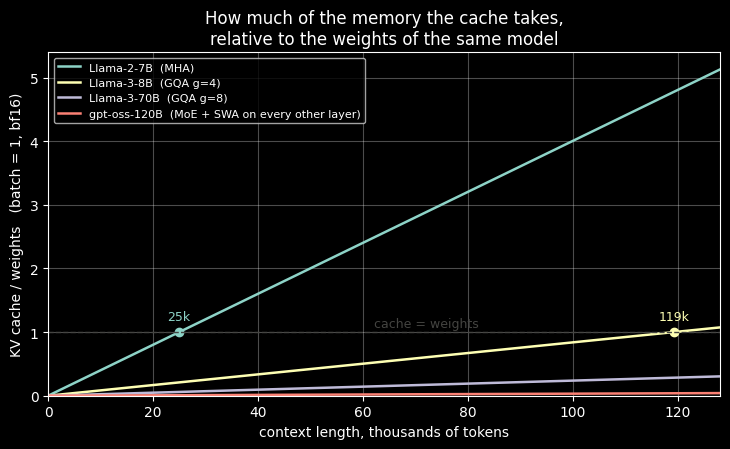

→ out\07_kv_share.png


In [189]:
B, Tp, d = 1, 512, cfg.d
flops_prefill = 2 * Tp * d * d          # one d×d weight matrix over the whole prompt
flops_decode = 2 * 1 * d * d            # the same one for a single token
bytes_weights = d * d * 2               # the weights have to be read in both cases
print(f"arithmetic intensity (FLOPs per byte of weights read), one d×d matrix:")
print(f"  prefill of {Tp} tokens: {flops_prefill / bytes_weights:>7.1f}")
print(f"  decode of 1 token:      {flops_decode / bytes_weights:>7.1f}")
print(f"  decode, batch 64:       {flops_decode * 64 / bytes_weights:>7.1f}")
print("""
A modern H100 needs ~300 FLOPs per byte in order not to idle.
Decode with batch 1 gives 1 — i.e. a core utilization of ~0.3%. All the remaining time
the GPU simply reads weights. This is not "a bad implementation", it is the nature of the task.
""")

# In gigabytes Llama-2-7B (512 KB/token) and Gemma-3-27B (496) differ by 3% and draw as one
# line. Their ratio to the weights differs fourfold, because the models are not the same size —
# so plot the ratio. It is also the quantity the section is about: the crossing of y=1 is the
# context length at which the cache stops being a detail and becomes the main consumer.
SHOWN = ["Llama-2-7B", "Llama-3-8B", "Llama-3-70B", "gpt-oss-120B"]   # one per attention scheme
seqs = np.arange(0, 131073, 1024)
fig, ax = plt.subplots(figsize=(7.4, 4.6))
for m, kv, w_gb, _ in rows:
    if m.name not in SHOWN:
        continue
    ratio = kv * seqs / 2 ** 30 / w_gb
    (line,) = ax.plot(seqs / 1024, ratio, lw=1.8, label=f"{m.name}  ({m.note})")
    cross = w_gb * 2 ** 30 / kv / 1024                 # where the cache equals the weights
    if cross <= seqs[-1] / 1024:
        ax.plot([cross], [1], "o", ms=6, color=line.get_color())
        ax.annotate(f"{cross:.0f}k", xy=(cross, 1), xytext=(0, 9),
                       textcoords="offset points", ha="center", fontsize=9,
                       color=line.get_color())
ax.axhline(1, ls="--", lw=1, c="#444441")
ax.text(62, 1.08, "cache = weights", fontsize=9, color="#444441")
ax.set_xlabel("context length, thousands of tokens")
ax.set_ylabel("KV cache / weights   (batch = 1, bf16)")
ax.set_xlim(0, 128); ax.set_ylim(0, 5.4)
ax.set_title("How much of the memory the cache takes,\nrelative to the weights of the same model")
ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "07_kv_share.png", dpi=140)
plt.show()
print(f"→ {OUT / '07_kv_share.png'}")

## 6. Checking the configs against Hugging Face (via the `--fetch` flag)

A useful habit and a good exercise: "read the model card as a config.json".
All the numbers above are taken from exactly there.

In [190]:
HF_IDS = {
    "Llama-3-8B": "meta-llama/Meta-Llama-3-8B",
    "Qwen3-32B": "Qwen/Qwen3-32B",
    "DeepSeek-V3": "deepseek-ai/DeepSeek-V3",
    "gpt-oss-120B": "openai/gpt-oss-120b",
    "Gemma-3-27B": "google/gemma-3-27b-it",
}
KEYS = ["num_hidden_layers", "hidden_size", "num_attention_heads", "num_key_value_heads",
        "head_dim", "kv_lora_rank", "qk_rope_head_dim", "sliding_window", "vocab_size",
        "rope_theta", "num_local_experts", "n_routed_experts", "num_experts_per_tok"]

if "--fetch" in sys.argv:
    for name, hid in HF_IDS.items():
        url = f"https://huggingface.co/{hid}/raw/main/config.json"
        try:
            with urllib.request.urlopen(url, timeout=15) as r:
                cfg_json = json.load(r)
        except Exception as e:
            print(f"{name:<14} — download failed ({type(e).__name__}); the model may be gated")
            continue
        got = {k: cfg_json.get(k) for k in KEYS if k in cfg_json}
        print(f"{name:<14} {got}")
else:
    print("Run with --fetch to download config.json and check the table above.")
    print("(gated repos such as Llama/Gemma will not serve it without a token — that is normal)")

Run with --fetch to download config.json and check the table above.
(gated repos such as Llama/Gemma will not serve it without a token — that is normal)


## Takeaways: the KV cache
* The KV cache turns generation from O(n²) into O(n) in compute — but pays for it in memory.
* Cache size = `2·L·n_kv·d_head·seq·batch·dtype`. Linear in length AND in batch.
* The whole evolution MHA → MQA → GQA and the appearance of sliding-window is a fight
  with exactly this number. The next section is about how precisely.
* Decode is memory-bound. That explains why inference is a separate engineering discipline
  and not "the same forward pass, just one token at a time".

---

# 08 — MHA → MQA → GQA: one axis, three solutions

**Lecture 1, block 3** (GQA as the SOTA standard).

The whole line of attention development after 2019 is a fight over the size of the KV cache.
Here we implement all three variants in a single class and check by experiment:

1. **how much** each variant saves (parameters + cache);
2. **how much** the MHA → GQA transition costs — we reproduce the "uptraining" from the GQA
   paper: average the KV heads of a trained model and see what happened to the loss
   immediately and after a short fine-tune.

Runtime ~2.5 minutes on CPU (there is a small training run inside).
Dependencies: `torch`, `matplotlib`.

Source: GQA — [arXiv:2305.13245](https://arxiv.org/abs/2305.13245).

In [191]:
from __future__ import annotations

import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)
torch.manual_seed(0)

## 1. One class — all three variants

MHA, MQA and GQA differ by exactly one number: how many KV heads there are
per `n_heads` Q heads. This is an interpolation, not three different ideas.

In [192]:
class GroupedAttention(nn.Module):
    """n_kv = n_heads → MHA;  n_kv = 1 → MQA;  1 < n_kv < n_heads → GQA."""

    def __init__(self, d: int, n_heads: int, n_kv: int):
        super().__init__()
        assert n_heads % n_kv == 0
        self.d, self.h, self.n_kv = d, n_heads, n_kv
        self.dh = d // n_heads
        self.wq = nn.Linear(d, n_heads * self.dh, bias=False)
        self.wk = nn.Linear(d, n_kv * self.dh, bias=False)
        self.wv = nn.Linear(d, n_kv * self.dh, bias=False)
        self.wo = nn.Linear(n_heads * self.dh, d, bias=False)

    def forward(self, x):
        B, T, _ = x.shape
        q = self.wq(x).view(B, T, self.h, self.dh).transpose(1, 2)
        k = self.wk(x).view(B, T, self.n_kv, self.dh).transpose(1, 2)
        v = self.wv(x).view(B, T, self.n_kv, self.dh).transpose(1, 2)
        rep = self.h // self.n_kv
        # The KV heads are "replicated" across groups. No extra cache memory:
        # what gets cached is k,v BEFORE repeat_interleave.
        y = F.scaled_dot_product_attention(
            q, k.repeat_interleave(rep, 1), v.repeat_interleave(rep, 1), is_causal=True)
        return self.wo(y.transpose(1, 2).reshape(B, T, -1))

    def kv_bytes_per_token(self, dtype=2) -> int:
        return 2 * self.n_kv * self.dh * dtype


d, H = 4096, 32
print(f"d_model={d}, n_heads={H}, d_head={d // H}   (a Llama-3-8B class config)\n")
print(f"{'variant':<14}{'n_kv':>6}{'attn parameters':>18}{'KB cache / layer / 1k tokens':>30}")
print("-" * 70)
for n_kv, tag in [(H, "MHA"), (8, "GQA g=4"), (4, "GQA g=8"), (1, "MQA")]:
    a = GroupedAttention(d, H, n_kv)
    p = sum(x.numel() for x in a.parameters())
    print(f"{tag:<14}{n_kv:>6}{p / 1e6:>15.1f}M{a.kv_bytes_per_token() * 1024 / 1024:>27.0f}")

print("""
Two observations:
  • Parameters are barely saved at all: W_Q and W_O stayed full, only W_K,W_V shrank.
    GQA is NOT a way to make the model smaller.
  • The cache falls by exactly h/g. That is the entire point: GQA is an INFERENCE optimization,
    not a training one. At training time (where there is no cache) it gives almost nothing.
""")

d_model=4096, n_heads=32, d_head=128   (a Llama-3-8B class config)

variant         n_kv   attn parameters  KB cache / layer / 1k tokens
----------------------------------------------------------------------
MHA               32           67.1M                      16384
GQA g=4            8           41.9M                       4096
GQA g=8            4           37.7M                       2048
MQA                1           34.6M                        512

Two observations:
  • Parameters are barely saved at all: W_Q and W_O stayed full, only W_K,W_V shrank.
    GQA is NOT a way to make the model smaller.
  • The cache falls by exactly h/g. That is the entire point: GQA is an INFERENCE optimization,
    not a training one. At training time (where there is no cache) it gives almost nothing.



## 2. Uptraining: what the MHA → GQA transition costs

The GQA paper proposes not training a GQA model from scratch but taking a ready MHA one
and **averaging the KV heads inside each group**, then fine-tuning a little (~5% of the
original compute). We check this on the toy repeat task — the same one the
induction-heads section used.

In [193]:
V, T, P_LO, P_HI = 128, 48, 8, 25
D_S, H_S, LAYERS = 96, 8, 2


def make_batch(bs: int, period: int | None = None):
    p = torch.full((bs, 1), period) if period else torch.randint(P_LO, P_HI, (bs, 1))
    base = torch.randint(0, V, (bs, T))
    return base.gather(1, torch.arange(T)[None, :] % p), p


class Block(nn.Module):
    def __init__(self, n_kv):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(D_S), nn.LayerNorm(D_S)
        self.attn = GroupedAttention(D_S, H_S, n_kv)
        self.mlp = nn.Sequential(nn.Linear(D_S, 4 * D_S), nn.GELU(), nn.Linear(4 * D_S, D_S))

    def forward(self, x):
        x = x + self.attn(self.n1(x))
        return x + self.mlp(self.n2(x))


class TinyLM(nn.Module):
    def __init__(self, n_kv=H_S):
        super().__init__()
        self.tok, self.pos = nn.Embedding(V, D_S), nn.Embedding(T, D_S)
        self.blocks = nn.ModuleList([Block(n_kv) for _ in range(LAYERS)])
        self.nf, self.head = nn.LayerNorm(D_S), nn.Linear(D_S, V, bias=False)

    def forward(self, idx):
        x = self.tok(idx) + self.pos(torch.arange(idx.size(1)))
        for b in self.blocks:
            x = b(x)
        return self.head(self.nf(x))


def lm_loss(m, bs=128):
    x, _ = make_batch(bs)
    lo = m(x)
    return F.cross_entropy(lo[:, :-1].reshape(-1, V), x[:, 1:].reshape(-1))


def fit(m, steps, lr=1e-3, bs=64):
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=0.01)
    for _ in range(steps):
        loss = lm_loss(m, bs)
        opt.zero_grad(); loss.backward(); opt.step()
    return m


TEACHER, FT, EVERY = 800, 300, 25       # the teacher is flat past ~800: 1.83 at 800, 1.80 at 1000

t0 = time.time()
torch.manual_seed(0)
mha = fit(TinyLM(n_kv=H_S), steps=TEACHER)
with torch.no_grad():
    base_loss = lm_loss(mha, 512).item()
print(f"MHA teacher: {TEACHER} steps, {time.time() - t0:.0f} s, loss = {base_loss:.3f} "
      f"(chance level {math.log(V):.3f})")

MHA teacher: 800 steps, 52 s, loss = 1.754 (chance level 4.852)


In [194]:
@torch.no_grad()
def convert_to_gqa(src: TinyLM, n_kv: int) -> TinyLM:
    """Mean-pooling the KV heads inside a group — exactly the recipe from the GQA paper."""
    dst = TinyLM(n_kv=n_kv)
    # everything except W_K/W_V is copied as is — the shapes match
    sd = {k: v for k, v in src.state_dict().items()
          if not k.endswith(("attn.wk.weight", "attn.wv.weight"))}
    dst.load_state_dict(sd, strict=False)
    for bs_, bd in zip(src.blocks, dst.blocks):
        dh, rep = bd.attn.dh, H_S // n_kv
        for name in ("wk", "wv"):
            w = getattr(bs_.attn, name).weight            # (H*dh, d)
            w = w.view(H_S, dh, -1).view(n_kv, rep, dh, -1).mean(1)   # average the group
            getattr(bd.attn, name).weight.copy_(w.reshape(n_kv * dh, -1))
    return dst


# Measuring every EVERY steps rather than twice costs nothing — the fine-tune is running
# anyway, only the evaluation is added. With two measurements the segment between them is a
# straight line drawn through territory where nothing was measured, and the shapes below
# differ precisely in that territory.
SHOW_AT = [0, 50, 150, FT]
print(f"\n{'variant':<12}{'cache':>8}" + "".join(f"{f'@{x}':>10}" for x in SHOW_AT))
print("-" * (20 + 10 * len(SHOW_AT)))
print(f"{'MHA (base)':<12}{'100%':>8}" + f"{base_loss:>10.3f}" * len(SHOW_AT))
curves = {}
for n_kv in (4, 2, 1):
    tag = "MQA" if n_kv == 1 else f"GQA g={H_S // n_kv}"
    m = convert_to_gqa(mha, n_kv)
    with torch.no_grad():
        hist, xs = [lm_loss(m, 512).item()], [0]
    for step in range(EVERY, FT + 1, EVERY):
        fit(m, steps=EVERY, lr=3e-4)
        with torch.no_grad():
            hist.append(lm_loss(m, 512).item())
        xs.append(step)
    curves[tag] = (xs, hist, 100 * n_kv / H_S)
    at = {x: h for x, h in zip(xs, hist)}
    print(f"{tag:<12}{100 * n_kv / H_S:>7.0f}%"
          + "".join(f"{at[x]:>10.3f}" for x in SHOW_AT))

mild, hard = curves["GQA g=2"][1], curves["MQA"][1]
print(f"""
Averaging the KV heads breaks the model on the spot: the loss jumps from {base_loss:.2f} to {min(h[1][0] for h in curves.values()):.1f}-{max(h[1][0] for h in curves.values()):.1f},
back towards the chance level of {math.log(V):.2f}. Nothing has been unlearned though — the
weights that matter are still there, and the fine-tune only has to teach the surviving KV heads
to serve several query heads at once.

How cheaply that goes depends on how hard you squeezed, and the three curves differ in SHAPE,
not just in where they end up:
  • GQA g=2 (half the cache) is essentially free — down to {mild[3]:.2f} within 75 steps and flat
    afterwards, ending at {mild[-1]:.2f} against the teacher's {base_loss:.2f};
  • GQA g=4 (a quarter) descends steadily for the whole run and lands at {curves['GQA g=4'][1][-1]:.2f};
  • MQA (one eighth) spends half the budget almost standing still — {hard[0]:.2f} to {hard[6]:.2f}
    over 150 steps — then covers {hard[6] - hard[-1]:.1f} more in the 150 that follow, and
    still ends at {hard[-1]:.2f}, a full nat above the teacher.

That last one is the argument against the extreme, and it is why the industry settled in the
middle: g=8 in Llama-3 and Qwen3 buys most of the cache back while the recovery stays cheap.

Two things this does NOT show. The task is a toy, so the absolute numbers do not transfer.
And this is a single run — the ordering of the three curves is what to take away, not the
exact step at which each one turns.
""")


variant        cache        @0       @50      @150      @300
------------------------------------------------------------
MHA (base)      100%     1.754     1.754     1.754     1.754
GQA g=2          50%     3.956     2.202     1.848     1.827
GQA g=4          25%     5.074     4.554     2.768     1.965
MQA              12%     5.264     4.830     4.592     2.743

Averaging the KV heads breaks the model on the spot: the loss jumps from 1.75 to 4.0-5.3,
back towards the chance level of 4.85. Nothing has been unlearned though — the
weights that matter are still there, and the fine-tune only has to teach the surviving KV heads
to serve several query heads at once.

How cheaply that goes depends on how hard you squeezed, and the three curves differ in SHAPE,
not just in where they end up:
  • GQA g=2 (half the cache) is essentially free — down to 1.98 within 75 steps and flat
    afterwards, ending at 1.83 against the teacher's 1.75;
  • GQA g=4 (a quarter) descends steadily for the whole

## 3. Final comparison on a real config

Llama-3-70B: 80 layers, 64 query heads, d_head=128, and GQA with g=8 (i.e. 8 KV heads).
The scheme it actually uses is one of the three; the other two are what the same model
would have cost.

variant              bytes/layer/token  KB/token (80 layers)   at 128k, GiB
----------------------------------------------------------------------------
MHA (would-be)                   32768               2560.0          320.0
GQA g=8 (actual)                  4096                320.0           40.0
MQA (would-be)                     512                 40.0            5.0


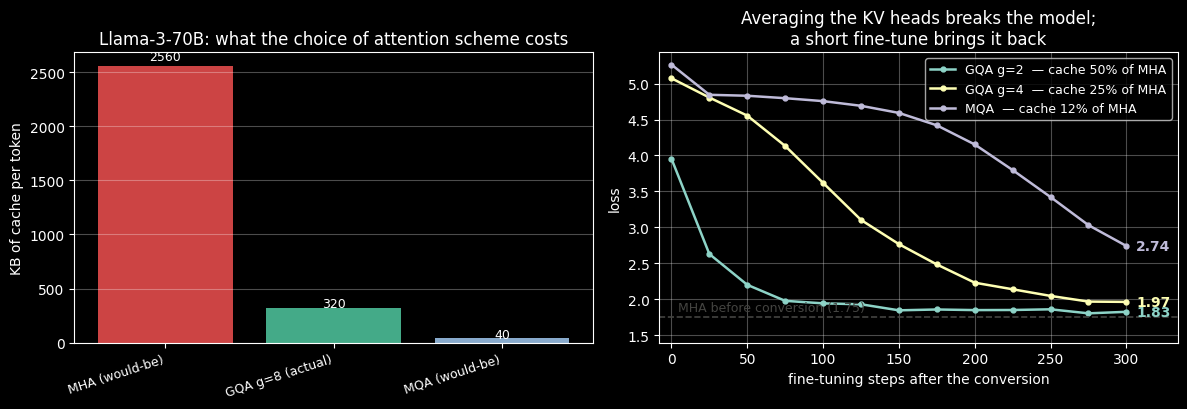


→ out\08_gqa.png


In [195]:
L70 = dict(layers=80, d=8192, n_heads=64, n_kv=8, d_head=128)
per_layer = {
    "MHA (would-be)": 2 * L70["n_heads"] * L70["d_head"] * 2,
    "GQA g=8 (actual)": 2 * L70["n_kv"] * L70["d_head"] * 2,
    "MQA (would-be)": 2 * 1 * L70["d_head"] * 2,
}
print(f"{'variant':<20}{'bytes/layer/token':>18}"
      f"{'KB/token (' + str(L70['layers']) + ' layers)':>22}{'at 128k, GiB':>15}")
print("-" * 76)
for name, b in per_layer.items():
    tot = b * L70["layers"]
    print(f"{name:<20}{b:>18}{tot / 1024:>21.1f}{tot * 131072 / 2 ** 30:>15.1f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(range(len(per_layer)), [v * L70["layers"] / 1024 for v in per_layer.values()],
          color=["#c44", "#4a8", "#8ac"])
ax[0].set_xticks(range(len(per_layer)))
ax[0].set_xticklabels(per_layer.keys(), rotation=18, ha="right", fontsize=9)
ax[0].set_ylabel("KB of cache per token")
ax[0].set_title("Llama-3-70B: what the choice of attention scheme costs")
ax[0].grid(alpha=.3, axis="y")
for i, v in enumerate(per_layer.values()):
    ax[0].text(i, v * L70["layers"] / 1024 * 1.02, f"{v * L70['layers'] / 1024:.0f}",
               ha="center", fontsize=9)

for tag, (xs, hist, share) in curves.items():
    (ln,) = ax[1].plot(xs, hist, "o-", ms=3.5, lw=1.8,
                       label=f"{tag}  \u2014 cache {share:.0f}% of MHA")
    ax[1].annotate(f"{hist[-1]:.2f}", xy=(xs[-1], hist[-1]), xytext=(7, 0),
                   textcoords="offset points", va="center", fontsize=10,
                   fontweight="bold", color=ln.get_color())
ax[1].axhline(base_loss, ls="--", lw=1.2, c="#444441")
ax[1].text(4, base_loss + .08, f"MHA before conversion ({base_loss:.2f})",
           fontsize=9, color="#444441")
ax[1].set_xlabel("fine-tuning steps after the conversion"); ax[1].set_ylabel("loss")
ax[1].set_xlim(-8, FT + 34); ax[1].set_ylim(bottom=1.4)
ax[1].set_title("Averaging the KV heads breaks the model;\na short fine-tune brings it back")
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "08_gqa.png", dpi=140)
plt.show()
print(f"\n→ {OUT / '08_gqa.png'}")

## Takeaways: MHA → MQA → GQA

| | what we cache | cache/token/layer (Llama-3-70B) | price |
|---|---|---|---|
| MHA | K,V of all heads | 32 KB | the quality reference, an unaffordable cache |
| GQA | K,V of groups | 4 KB (g=8) | almost free in quality — the industry default |
| MQA | K,V of a single head | 0.5 KB | a noticeable drop, rarely used in pure form |

The main idea of this block: this is **one axis**, and everybody moves along it in the same
direction. GQA won because it is the only point on that axis where the cache drops by an
order of magnitude and the quality does not — and because an existing MHA checkpoint can be
converted with a short fine-tune instead of being retrained.

**Not covered here:** sliding-window and attention sinks, low-rank KV compression
(the MLA line in DeepSeek), linear attention / SSM, learned sparse routing.